# Vision Transformers — PyTorch Pipeline

## Model: ViT-Small (from scratch) + Pre-trained ViT-B/16 (fine-tuned)
- **Dataset**: CIFAR-100 — 45,000 train / 5,000 val / 10,000 test, 32x32x3 RGB images (reused from CNN #11)
- **Task**: Classify 100 fine classes (20 superclasses) — direct architecture comparison with CNN #11's ResNet-20
- **Framework showcase**: Full ViT from scratch — patch embedding via Conv2d, learnable positional embedding, multi-head self-attention, CLS/DIST tokens, DeiT distillation. No `nn.TransformerEncoder` or `nn.MultiheadAttention`.

## Evaluation Strategy
- **Metrics**: Test accuracy, Macro F1, per-class F1, fine-class (100) + superclass (20) hierarchical accuracy
- **Key experiments**: Vanilla vs training recipe impact, distillation from own CNN teacher, pre-training vs from-scratch gap
- **Visuals**: Positional embedding heatmap, CLS-to-patch attention overlays, attention rollout (Abnar & Zuidema), multi-head attention grid, variant progression chart with CNN #11 baseline line

## Pipeline
1. Setup + load CIFAR-100 data
2. Patch embedding + learnable positional embedding (architecture component, visualized)
3. ViT encoder block + full model assembly (MHSA + MLP, from scratch)
4. Variant 1: Vanilla ViT-Small from scratch (expected ~55-65%, below CNN baseline)
5. Variant 2: DeiT training recipe (RandAugment + MixUp + CutMix + stochastic depth, 300 epochs) — expected ~72-78%
6. Variant 3: DeiT distillation using CNN #11 ResNet-20 as teacher — expected ~76-82%
7. Variant 4: Fine-tune pre-trained ViT-B/16 (HuggingFace, resize to 224x224) — expected ~90-93%
8. Classification evaluation (all 4 variants + CNN #11 baseline)
9. Attention visualization (CLS-to-patches overlays, rollout, multi-head grid)
10. Variant progression chart (portfolio centerpiece with baseline line)
11. Performance benchmarks (training time, inference, params)
12. Save results

In [1]:
# Step 1: Setup + Data Loading

# Imports
import json
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

# Add project root to path for utils import
PROJECT_ROOT = Path('../..').resolve()
sys.path.insert(0, str(PROJECT_ROOT))

from utils.performance import track_performance, track_inference, get_model_size
from utils.results import save_results, add_result, print_comparison
from utils.metrics import macro_f1_score
from utils.visualization import (
    plot_confusion_matrix_multiclass,
    plot_superclass_confusion,
    plot_multihead_grid,
    plot_bleu_progression,
    plot_attention_overlay,
    plot_attention_grid_samples,
)
from utils.vit_utils import (
    apply_mixup_cutmix,
    distillation_loss,
    attention_rollout,
    cls_attention_map,
)

# Reproducibility
RANDOM_STATE = 113
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.backends.cudnn.benchmark = True  # faster fixed-shape training on RTX 4090

# Architecture (ViT-Small for Variants 1-3; V4 uses HuggingFace config)
PATCH_SIZE = 4
NUM_PATCHES = 64           # (32 / 4) ** 2
D_MODEL = 384
N_HEADS = 6                # d_k = 384 / 6 = 64
N_ENCODER_LAYERS = 6
D_FF = 1536                # 4 * d_model
DROPOUT = 0.1
STOCHASTIC_DEPTH = 0.1     # Variants 2-3 only
NUM_CLASSES = 100
IMAGE_SIZE = 32

# Training (shared defaults; variants override where needed)
BATCH_SIZE = 128
LR_PEAK = 5e-4
WEIGHT_DECAY = 0.05
WARMUP_EPOCHS = 10
LABEL_SMOOTHING = 0.1
GRAD_CLIP = 1.0

# Per-variant epoch counts
EPOCHS_VANILLA = 100
EPOCHS_RECIPE = 300
EPOCHS_DISTILL = 300
EPOCHS_FINETUNE = 15

# DeiT augmentation recipe (Variants 2-3)
RAND_AUG_N = 2
RAND_AUG_M = 9
MIXUP_ALPHA = 0.8
CUTMIX_ALPHA = 1.0
RANDOM_ERASE_P = 0.25
MIXUP_CUTMIX_PROB = 0.5

# Distillation (Variant 3)
DISTILL_TYPE = 'hard'
DISTILL_ALPHA = 0.5

# Pre-trained fine-tune (Variant 4)
PRETRAIN_MODEL_ID = 'google/vit-base-patch16-224-in21k'
RESIZE_DIM = 224
FINETUNE_LR = 2e-5
FINETUNE_WD = 0.01

# Paths
DATA_DIR = PROJECT_ROOT / 'data' / 'processed' / 'cnn'
RESULTS_DIR = Path('results')
RESULTS_DIR.mkdir(exist_ok=True)
TEACHER_CHECKPOINT = PROJECT_ROOT / 'PyTorch' / '11-cnn' / 'results' / 'resnet20_best.pth'

# Device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("=" * 60)
print("[1/12] SETUP + DATA LOADING")
print("=" * 60)

# Load CIFAR-100 (reused from CNN #11 preprocessing)
X_train_np = np.load(DATA_DIR / 'X_train.npy')
X_test_np = np.load(DATA_DIR / 'X_test.npy')
y_train_np = np.load(DATA_DIR / 'y_train_fine.npy')
y_test_np = np.load(DATA_DIR / 'y_test_fine.npy')

with open(DATA_DIR / 'preprocessing_info.json') as f:
    info = json.load(f)
fine_class_names = info['fine_class_names']
coarse_class_names = info['coarse_class_names']

# Numpy (B, H, W, C) -> PyTorch (B, C, H, W)
X_train_full = torch.from_numpy(X_train_np).permute(0, 3, 1, 2).float()
X_test = torch.from_numpy(X_test_np).permute(0, 3, 1, 2).float()
y_train_full = torch.from_numpy(y_train_np).long()
y_test = torch.from_numpy(y_test_np).long()

# Train/val split: 45K train / 5K val (seeded for reproducibility)
VAL_SIZE = 5000
split_gen = torch.Generator().manual_seed(RANDOM_STATE)
perm = torch.randperm(X_train_full.size(0), generator=split_gen)
val_idx = perm[:VAL_SIZE]
train_idx = perm[VAL_SIZE:]
X_train = X_train_full[train_idx]
y_train = y_train_full[train_idx]
X_val = X_train_full[val_idx]
y_val = y_train_full[val_idx]

# Basic DataLoaders (Variant 1 uses these directly; Variants 2+ rebuild train_loader)
train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=0, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=0, pin_memory=True)

# Print verification
print(f"\nDevice: {DEVICE}")
if DEVICE.type == 'cuda':
    print(f"    GPU:  {torch.cuda.get_device_name(0)}")
    print(f"    VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

print(f"\nData shapes (channel-first PyTorch convention):")
print(f"    X_train:  {tuple(X_train.shape)}    dtype: {X_train.dtype}    range: [{X_train.min():.3f}, {X_train.max():.3f}]")
print(f"    X_val:    {tuple(X_val.shape)}")
print(f"    X_test:   {tuple(X_test.shape)}")
print(f"    y_train:  {tuple(y_train.shape)}    dtype: {y_train.dtype}    classes: {len(torch.unique(y_train))}")
print(f"    y_val:    {tuple(y_val.shape)}")
print(f"    y_test:   {tuple(y_test.shape)}")

print(f"\nDataLoader config (batch_size={BATCH_SIZE}):")
print(f"    Train batches: {len(train_loader)}")
print(f"    Val batches:   {len(val_loader)}")
print(f"    Test batches:  {len(test_loader)}")

print(f"\nPaths:")
print(f"    Data:            {DATA_DIR}")
print(f"    Results:         {RESULTS_DIR.resolve()}")
print(f"    Teacher ckpt:    {TEACHER_CHECKPOINT}")
print(f"    Teacher exists:  {TEACHER_CHECKPOINT.exists()}")

print(f"\nBaselines to compare (CNN #11 ResNet-20):")
print(f"    PyTorch:    80.1% test accuracy")
print(f"    TensorFlow: 79.5% test accuracy")

[1/12] SETUP + DATA LOADING

Device: cuda
    GPU:  NVIDIA GeForce RTX 4090
    VRAM: 25.8 GB

Data shapes (channel-first PyTorch convention):
    X_train:  (45000, 3, 32, 32)    dtype: torch.float32    range: [0.000, 1.000]
    X_val:    (5000, 3, 32, 32)
    X_test:   (10000, 3, 32, 32)
    y_train:  (45000,)    dtype: torch.int64    classes: 100
    y_val:    (5000,)
    y_test:   (10000,)

DataLoader config (batch_size=128):
    Train batches: 352
    Val batches:   40
    Test batches:  79

Paths:
    Data:            C:\Users\Max\Desktop\Coding\.Projects\2026\ml-framework-comparisons\data\processed\cnn
    Results:         C:\Users\Max\Desktop\Coding\.Projects\2026\ml-framework-comparisons\PyTorch\17-vit\results
    Teacher ckpt:    C:\Users\Max\Desktop\Coding\.Projects\2026\ml-framework-comparisons\PyTorch\11-cnn\results\resnet20_best.pth
    Teacher exists:  True

Baselines to compare (CNN #11 ResNet-20):
    PyTorch:    80.1% test accuracy
    TensorFlow: 79.5% test accuracy


In [2]:
# Step 2: Patch Embedding + Positional Embedding

class PatchEmbed(nn.Module):
    """
    Split image into patches, linearly project each to d_model.

    Uses the patch-as-conv trick: a Conv2d with kernel_size=patch_size and
    stride=patch_size is mathematically equivalent to reshaping the image
    into patches and applying a linear projection (ViT paper Appendix A).
    Conv2d is ~15% faster on GPU than explicit reshape + Linear.

    Input:  (B, C, H, W)    RGB image tensor
    Output: (B, num_patches, d_model)
    """
    def __init__(self, image_size=32, patch_size=4, in_channels=3, d_model=384):
        super().__init__()
        assert image_size % patch_size == 0, \
            f"image_size {image_size} must be divisible by patch_size {patch_size}"
        self.num_patches = (image_size // patch_size) ** 2
        # Conv with kernel=stride=patch_size acts as patch extractor + linear projection
        self.proj = nn.Conv2d(in_channels, d_model,
                              kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        # (B, C, H, W) -> (B, d_model, H/p, W/p)
        x = self.proj(x)
        # Flatten spatial dims -> (B, d_model, num_patches) -> (B, num_patches, d_model)
        x = x.flatten(2).transpose(1, 2)
        return x

class ViTEmbedding(nn.Module):
    """
    Patch embedding + learnable [CLS] token + learnable positional embedding.

    Forward output is (B, 1 + num_patches, d_model), ready for encoder blocks.

    Positional embedding is LEARNABLE (not sinusoidal as in Transformers #16).
    ViT (Dosovitskiy 2020) and DeiT (Touvron 2020) both use learnable PE --
    for fixed-size inputs it matches or exceeds sinusoidal, and flexibility
    is hypothesized to help compensate for ViT's lack of spatial inductive bias.

    [CLS] token: a learnable vector prepended to the patch sequence. After
    attention, its final representation serves as the image-level feature for
    classification -- analogous to BERT's [CLS] for sentence-level tasks.
    """
    def __init__(self, image_size=32, patch_size=4, in_channels=3,
                 d_model=384, dropout=0.1):
        super().__init__()
        self.patch_embed = PatchEmbed(image_size, patch_size, in_channels, d_model)
        num_patches = self.patch_embed.num_patches

        # [CLS] token: shape (1, 1, d_model) -- broadcasts over the batch
        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))

        # Positional embedding: (1, 1 + num_patches, d_model). +1 slot for [CLS]
        self.pos_embed = nn.Parameter(torch.zeros(1, 1 + num_patches, d_model))

        self.dropout = nn.Dropout(dropout)

        # Init: truncated normal std=0.02 (ViT paper + DeiT standard; avoids
        # initialization outliers that can destabilize early training)
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

    def forward(self, x):
        B = x.size(0)
        # Patch embed: (B, C, H, W) -> (B, num_patches, d_model)
        x = self.patch_embed(x)

        # Prepend [CLS]: broadcast (1, 1, d_model) -> (B, 1, d_model), then concat
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls_tokens, x], dim=1)  # (B, 1 + num_patches, d_model)

        # Add learnable positional embedding (broadcasts along batch dim)
        x = x + self.pos_embed

        return self.dropout(x)

# Sanity check instance (standalone; the full ViT will build its own in the next section)
_embed = ViTEmbedding(
    image_size=IMAGE_SIZE, patch_size=PATCH_SIZE, in_channels=3,
    d_model=D_MODEL, dropout=DROPOUT
).to(DEVICE)

print("=" * 60)
print("[2/12] PATCH EMBEDDING + POSITIONAL EMBEDDING")
print("=" * 60)

# Forward-pass shape check on a real batch
sample_batch, _ = next(iter(train_loader))
sample_batch = sample_batch.to(DEVICE)
embedded = _embed(sample_batch)

print(f"\nForward pass shape check:")
print(f"    Input:     {tuple(sample_batch.shape)}    (B, C, H, W)")
print(f"    Output:    {tuple(embedded.shape)}    (B, 1 + num_patches, d_model)")
print(f"    Expected:  ({BATCH_SIZE}, {1 + NUM_PATCHES}, {D_MODEL})")
print(f"    Match:     {tuple(embedded.shape) == (BATCH_SIZE, 1 + NUM_PATCHES, D_MODEL)}")

print(f"\nModule parameters:")
patch_params = sum(p.numel() for p in _embed.patch_embed.parameters())
cls_params = _embed.cls_token.numel()
pe_params = _embed.pos_embed.numel()
total = patch_params + cls_params + pe_params
print(f"    Patch embed Conv2d:  {patch_params:,}")
print(f"    [CLS] token:         {cls_params:,}")
print(f"    Positional embed:    {pe_params:,}")
print(f"    Total:               {total:,}")

# Free the sanity instance
del _embed
torch.cuda.empty_cache()

[2/12] PATCH EMBEDDING + POSITIONAL EMBEDDING

Forward pass shape check:
    Input:     (128, 3, 32, 32)    (B, C, H, W)
    Output:    (128, 65, 384)    (B, 1 + num_patches, d_model)
    Expected:  (128, 65, 384)
    Match:     True

Module parameters:
    Patch embed Conv2d:  18,816
    [CLS] token:         384
    Positional embed:    24,960
    Total:               44,160


In [3]:
# Step 3: ViT Encoder Block + Full Model

class MultiHeadSelfAttention(nn.Module):
    """
    Multi-head self-attention: queries, keys, values all come from the same
    input (no cross-attention as in Transformers #16 decoder).

    Fused QKV projection: one matmul (d_model -> 3*d_model) instead of three
    separate projections. Reshape splits into heads post-projection. Optional
    attention return for future visualization; returns pre-dropout attention
    probabilities since dropout is not semantically meaningful for viz.
    """
    def __init__(self, d_model, n_heads, dropout=0.0):
        super().__init__()
        assert d_model % n_heads == 0, \
            f"d_model {d_model} must be divisible by n_heads {n_heads}"
        self.n_heads = n_heads
        self.d_k = d_model // n_heads
        self.scale = self.d_k ** -0.5

        self.qkv = nn.Linear(d_model, 3 * d_model)
        self.proj = nn.Linear(d_model, d_model)
        self.attn_dropout = nn.Dropout(dropout)
        self.proj_dropout = nn.Dropout(dropout)

    def forward(self, x, return_attn=False):
        B, N, D = x.shape
        # Fused QKV: (B, N, 3*D) -> (B, N, 3, n_heads, d_k) -> (3, B, n_heads, N, d_k)
        qkv = self.qkv(x).reshape(B, N, 3, self.n_heads, self.d_k).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]  # each: (B, n_heads, N, d_k)

        # Scaled dot-product attention
        attn_scores = (q @ k.transpose(-2, -1)) * self.scale       # (B, n_heads, N, N)
        attn_probs_raw = attn_scores.softmax(dim=-1)               # pre-dropout, for viz
        attn_probs = self.attn_dropout(attn_probs_raw)

        # Weighted sum of values, then merge heads back
        out = attn_probs @ v                                        # (B, n_heads, N, d_k)
        out = out.transpose(1, 2).reshape(B, N, D)                  # (B, N, D)
        out = self.proj_dropout(self.proj(out))

        if return_attn:
            return out, attn_probs_raw
        return out

class MLP(nn.Module):
    """
    Feed-forward block: d_model -> d_ff -> d_model with GELU activation.

    ViT/DeiT use GELU (not ReLU) -- smoother gradient, empirically better
    for Transformers. d_ff = 4 * d_model is the standard expansion ratio.
    Dropout applied after both Linears per ViT paper.
    """
    def __init__(self, d_model, d_ff, dropout=0.0):
        super().__init__()
        self.fc1 = nn.Linear(d_model, d_ff)
        self.act = nn.GELU()
        self.fc2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = self.dropout(self.act(self.fc1(x)))
        x = self.dropout(self.fc2(x))
        return x

class StochasticDepth(nn.Module):
    """
    Per-sample random layer drop, aka DropPath (Huang et al. 2016, adapted
    for Transformers in DeiT). With probability drop_prob, zero the block's
    output so the residual passes through unchanged. During training only.

    Regularizes deep stacks without reducing model capacity at eval time.
    Vanilla (Variant 1) uses drop_prob=0; DeiT recipe (Variants 2-3) uses 0.1.
    """
    def __init__(self, drop_prob=0.0):
        super().__init__()
        self.drop_prob = drop_prob

    def forward(self, x):
        if self.drop_prob == 0.0 or not self.training:
            return x
        keep = 1.0 - self.drop_prob
        # Per-sample binary mask: (B, 1, 1) broadcasts over sequence + features
        mask = x.new_empty(x.size(0), 1, 1).bernoulli_(keep)
        # Inverted dropout: rescale by 1/keep so expected value is unchanged
        return x * mask / keep

class EncoderBlock(nn.Module):
    """
    ViT encoder block with Pre-LN residuals and optional stochastic depth.

    Pre-LN: x + Attn(LN(x))  -- ViT/DeiT standard, stable for deep stacks.
    Contrast with Post-LN (Transformers #16): LN(x + Attn(x)), which was
    the original 2017 Transformer formulation but fights warmup schedules.
    """
    def __init__(self, d_model, n_heads, d_ff, dropout=0.0, drop_path=0.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.attn = MultiHeadSelfAttention(d_model, n_heads, dropout)
        self.drop_path1 = StochasticDepth(drop_path)

        self.norm2 = nn.LayerNorm(d_model)
        self.mlp = MLP(d_model, d_ff, dropout)
        self.drop_path2 = StochasticDepth(drop_path)

    def forward(self, x, return_attn=False):
        # Pre-LN self-attention + residual + stochastic depth
        if return_attn:
            attn_out, attn_probs = self.attn(self.norm1(x), return_attn=True)
        else:
            attn_out = self.attn(self.norm1(x))
            attn_probs = None
        x = x + self.drop_path1(attn_out)

        # Pre-LN MLP + residual + stochastic depth
        x = x + self.drop_path2(self.mlp(self.norm2(x)))

        if return_attn:
            return x, attn_probs
        return x

class ViT(nn.Module):
    """
    Vision Transformer (encoder-only).

    Structure:
        Image (B, 3, H, W)
        -> ViTEmbedding (patches + CLS prepend + learnable PE + dropout)
        -> N x EncoderBlock (Pre-LN MHSA + MLP with residuals + stochastic depth)
        -> Final LayerNorm
        -> Classification head on [CLS] token

    The [CLS] token at position 0 aggregates information via attention across
    all patches. Its final LayerNorm'd vector is projected to class logits.
    """
    def __init__(self, image_size=32, patch_size=4, in_channels=3, num_classes=100,
                 d_model=384, n_heads=6, n_layers=6, d_ff=1536, dropout=0.1,
                 drop_path=0.0):
        super().__init__()
        self.embedding = ViTEmbedding(image_size, patch_size, in_channels,
                                      d_model, dropout)
        self.blocks = nn.ModuleList([
            EncoderBlock(d_model, n_heads, d_ff, dropout, drop_path)
            for _ in range(n_layers)
        ])
        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, num_classes)

        # Classification head init: small truncated normal on weight, zero bias
        nn.init.trunc_normal_(self.head.weight, std=0.02)
        nn.init.zeros_(self.head.bias)

    def forward(self, x, return_attn=False):
        x = self.embedding(x)

        attn_maps = []
        for block in self.blocks:
            if return_attn:
                x, attn_probs = block(x, return_attn=True)
                attn_maps.append(attn_probs)
            else:
                x = block(x)

        x = self.norm(x)
        cls_final = x[:, 0]              # [CLS] at position 0
        logits = self.head(cls_final)

        if return_attn:
            return logits, attn_maps
        return logits

# Instantiate + shape check
print("=" * 60)
print("[3/12] ViT ENCODER BLOCK + FULL MODEL")
print("=" * 60)

model = ViT(
    image_size=IMAGE_SIZE, patch_size=PATCH_SIZE, in_channels=3,
    num_classes=NUM_CLASSES, d_model=D_MODEL, n_heads=N_HEADS,
    n_layers=N_ENCODER_LAYERS, d_ff=D_FF, dropout=DROPOUT,
    drop_path=0.0,  # Variant 1 (Vanilla) disables stochastic depth
).to(DEVICE)

# Forward pass in eval mode for deterministic shape check
sample_batch, _ = next(iter(train_loader))
sample_batch = sample_batch.to(DEVICE)
model.eval()
with torch.no_grad():
    logits, attn_list = model(sample_batch, return_attn=True)
model.train()

print(f"\nForward pass (return_attn=True):")
print(f"    Input:      {tuple(sample_batch.shape)}")
print(f"    Logits:     {tuple(logits.shape)}    expected: ({BATCH_SIZE}, {NUM_CLASSES})")
print(f"    Attn maps:  {len(attn_list)} layers, each {tuple(attn_list[0].shape)}")
print(f"    Expected:   {N_ENCODER_LAYERS} layers, each ({BATCH_SIZE}, {N_HEADS}, 65, 65)")

# Parameter breakdown
total_params = sum(p.numel() for p in model.parameters())
embed_params = sum(p.numel() for p in model.embedding.parameters())
blocks_params = sum(p.numel() for p in model.blocks.parameters())
norm_params = sum(p.numel() for p in model.norm.parameters())
head_params = sum(p.numel() for p in model.head.parameters())

print(f"\nModel parameters:")
print(f"    Embedding (patch + CLS + PE):  {embed_params:,}")
print(f"    Encoder blocks ({N_ENCODER_LAYERS}x):            {blocks_params:,}")
print(f"    Final LayerNorm:               {norm_params:,}")
print(f"    Classification head:           {head_params:,}")
print(f"    Total:                         {total_params:,}")
print(f"    Target (ViT-Small 6L/d=384):   ~10-11M")

[3/12] ViT ENCODER BLOCK + FULL MODEL

Forward pass (return_attn=True):
    Input:      (128, 3, 32, 32)
    Logits:     (128, 100)    expected: (128, 100)
    Attn maps:  6 layers, each (128, 6, 65, 65)
    Expected:   6 layers, each (128, 6, 65, 65)

Model parameters:
    Embedding (patch + CLS + PE):  44,160
    Encoder blocks (6x):            10,646,784
    Final LayerNorm:               768
    Classification head:           38,500
    Total:                         10,730,212
    Target (ViT-Small 6L/d=384):   ~10-11M


In [4]:
# Step 4a: Variant 1 (Vanilla) — Setup

import math
from torchvision.transforms import v2 as T

# V1 augmentation: basic crop + flip (no MixUp / CutMix / RandAugment)
v1_transform = T.Compose([
    T.RandomCrop(IMAGE_SIZE, padding=4),
    T.RandomHorizontalFlip(),
])

# Dataset wrapper that applies an optional torchvision transform per sample
class AugmentedDataset(torch.utils.data.Dataset):
    # Wraps pre-loaded tensors with an optional transform applied in __getitem__
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]
        if self.transform is not None:
            img = self.transform(img)
        return img, self.labels[idx]

# Rebuild train loader with V1 augmentation (val/test loaders from Cell 1 stay as-is)
v1_train_dataset = AugmentedDataset(X_train, y_train, transform=v1_transform)
v1_train_loader = DataLoader(v1_train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                             num_workers=0, pin_memory=True)

# Fresh ViT model (reseed before instantiation for reproducibility)
torch.manual_seed(RANDOM_STATE)
v1_model = ViT(
    image_size=IMAGE_SIZE, patch_size=PATCH_SIZE, in_channels=3,
    num_classes=NUM_CLASSES, d_model=D_MODEL, n_heads=N_HEADS,
    n_layers=N_ENCODER_LAYERS, d_ff=D_FF, dropout=DROPOUT,
    drop_path=0.0,  # V1: no stochastic depth
).to(DEVICE)

# Optimizer: AdamW (decoupled weight decay, standard for ViT)
v1_optimizer = torch.optim.AdamW(v1_model.parameters(), lr=LR_PEAK,
                                 weight_decay=WEIGHT_DECAY)

# LR schedule: linear warmup then cosine decay, stepped per-batch for smoothness
v1_total_steps = EPOCHS_VANILLA * len(v1_train_loader)
v1_warmup_steps = WARMUP_EPOCHS * len(v1_train_loader)
V1_ETA_MIN_RATIO = 0.01  # final LR = 1% of peak (not fully zero)

def v1_lr_lambda(step):
    if step < v1_warmup_steps:
        # Linear warmup: 0 -> 1 (scales LR_PEAK)
        return step / max(1, v1_warmup_steps)
    # Cosine decay: 1 -> eta_min_ratio
    progress = (step - v1_warmup_steps) / max(1, v1_total_steps - v1_warmup_steps)
    cosine = 0.5 * (1.0 + math.cos(math.pi * progress))
    return V1_ETA_MIN_RATIO + (1.0 - V1_ETA_MIN_RATIO) * cosine

v1_scheduler = torch.optim.lr_scheduler.LambdaLR(v1_optimizer, lr_lambda=v1_lr_lambda)

# Loss: CrossEntropy with label smoothing (no MixUp, so hard-label targets)
v1_criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

# Setup summary
print("=" * 60)
print("[4a/12] VARIANT 1 — VANILLA ViT-SMALL SETUP")
print("=" * 60)

print(f"\nAugmentation (V1 basic):")
print(f"    RandomCrop({IMAGE_SIZE}, padding=4)")
print(f"    RandomHorizontalFlip()")
print(f"    (no MixUp / CutMix / RandAugment — intentionally minimal for baseline)")

print(f"\nModel: ViT-Small (drop_path=0.0)")
print(f"    Params: {sum(p.numel() for p in v1_model.parameters()):,}")

print(f"\nOptimizer: AdamW")
print(f"    LR peak:       {LR_PEAK}")
print(f"    Weight decay:  {WEIGHT_DECAY}")
print(f"    Betas:         (0.9, 0.999) [PyTorch defaults]")

print(f"\nLR Schedule: linear warmup -> cosine decay (per-step)")
print(f"    Epochs total:   {EPOCHS_VANILLA}")
print(f"    Warmup epochs:  {WARMUP_EPOCHS}")
print(f"    Total steps:    {v1_total_steps:,}")
print(f"    Warmup steps:   {v1_warmup_steps:,}")
print(f"    eta_min:        {LR_PEAK * V1_ETA_MIN_RATIO}  ({V1_ETA_MIN_RATIO * 100:.0f}% of peak)")

print(f"\nLoss: CrossEntropyLoss")
print(f"    Label smoothing: {LABEL_SMOOTHING}")
print(f"    (hard labels; MixUp/CutMix arrive in V2)")

print(f"\nGradient clipping: max_norm = {GRAD_CLIP}")
print(f"\nTrain batches/epoch: {len(v1_train_loader)}")

[4a/12] VARIANT 1 — VANILLA ViT-SMALL SETUP

Augmentation (V1 basic):
    RandomCrop(32, padding=4)
    RandomHorizontalFlip()
    (no MixUp / CutMix / RandAugment — intentionally minimal for baseline)

Model: ViT-Small (drop_path=0.0)
    Params: 10,730,212

Optimizer: AdamW
    LR peak:       0.0005
    Weight decay:  0.05
    Betas:         (0.9, 0.999) [PyTorch defaults]

LR Schedule: linear warmup -> cosine decay (per-step)
    Epochs total:   100
    Warmup epochs:  10
    Total steps:    35,200
    Warmup steps:   3,520
    eta_min:        5e-06  (1% of peak)

Loss: CrossEntropyLoss
    Label smoothing: 0.1
    (hard labels; MixUp/CutMix arrive in V2)

Gradient clipping: max_norm = 1.0

Train batches/epoch: 352


In [5]:
# Step 4b: Variant 1 Training Loop (100 epochs)

print("=" * 60)
print("[4b/12] VARIANT 1 — TRAINING LOOP (100 epochs)")
print("=" * 60)
print("Starting training...\n", flush=True)

v1_history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'lr': []}
v1_best_val_acc = 0.0
v1_best_state = None
v1_best_epoch = 0
V1_CHECKPOINT_PATH = RESULTS_DIR / 'v1_vanilla_best.pth'

with track_performance(gpu=True) as v1_perf:
    for epoch in range(EPOCHS_VANILLA):
        # Training
        v1_model.train()
        running_train_loss = 0.0
        for images, labels in v1_train_loader:
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            v1_optimizer.zero_grad(set_to_none=True)
            logits = v1_model(images)
            loss = v1_criterion(logits, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(v1_model.parameters(), max_norm=GRAD_CLIP)
            v1_optimizer.step()
            v1_scheduler.step()

            running_train_loss += loss.item()
        train_loss = running_train_loss / len(v1_train_loader)

        # Validation
        v1_model.eval()
        running_val_loss = 0.0
        correct, total = 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(DEVICE, non_blocking=True)
                labels = labels.to(DEVICE, non_blocking=True)
                logits = v1_model(images)
                running_val_loss += v1_criterion(logits, labels).item()
                correct += (logits.argmax(-1) == labels).sum().item()
                total += labels.size(0)
        val_loss = running_val_loss / len(val_loader)
        val_acc = correct / total
        current_lr = v1_optimizer.param_groups[0]['lr']

        v1_history['train_loss'].append(train_loss)
        v1_history['val_loss'].append(val_loss)
        v1_history['val_acc'].append(val_acc)
        v1_history['lr'].append(current_lr)

        # Track + persist best by val accuracy
        improved = val_acc > v1_best_val_acc
        if improved:
            v1_best_val_acc = val_acc
            v1_best_epoch = epoch + 1
            v1_best_state = {k: v.detach().cpu().clone()
                             for k, v in v1_model.state_dict().items()}
            torch.save(v1_best_state, V1_CHECKPOINT_PATH)

        flag = " *" if improved else "  "
        print(f"Epoch {epoch+1:3d}/{EPOCHS_VANILLA} | "
              f"train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | "
              f"val_acc={val_acc:.4f} | lr={current_lr:.2e}{flag}",
              flush=True)

    torch.cuda.synchronize()  # ensure GPU ops complete for accurate timing

print("\n" + "=" * 60)
print("Training complete")
print("=" * 60)
print(f"    Best val accuracy: {v1_best_val_acc:.4f} (epoch {v1_best_epoch}/{EPOCHS_VANILLA})")
print(f"    Final val accuracy: {val_acc:.4f}")
print(f"    Total training time: {v1_perf['time']/60:.1f} min ({v1_perf['time']:.1f}s)")
print(f"    Peak GPU memory:    {v1_perf['gpu_memory']:.1f} MB")
print(f"    Best checkpoint:    {V1_CHECKPOINT_PATH}")

[4b/12] VARIANT 1 — TRAINING LOOP (100 epochs)
Starting training...

Epoch   1/100 | train_loss=4.4301 | val_loss=4.2303 | val_acc=0.0658 | lr=5.00e-05 *
Epoch   2/100 | train_loss=4.0505 | val_loss=3.8748 | val_acc=0.1190 | lr=1.00e-04 *
Epoch   3/100 | train_loss=3.7741 | val_loss=3.6142 | val_acc=0.1764 | lr=1.50e-04 *
Epoch   4/100 | train_loss=3.6073 | val_loss=3.5290 | val_acc=0.1950 | lr=2.00e-04 *
Epoch   5/100 | train_loss=3.4828 | val_loss=3.3776 | val_acc=0.2298 | lr=2.50e-04 *
Epoch   6/100 | train_loss=3.3871 | val_loss=3.3180 | val_acc=0.2386 | lr=3.00e-04 *
Epoch   7/100 | train_loss=3.3138 | val_loss=3.2403 | val_acc=0.2722 | lr=3.50e-04 *
Epoch   8/100 | train_loss=3.2544 | val_loss=3.1980 | val_acc=0.2712 | lr=4.00e-04  
Epoch   9/100 | train_loss=3.2144 | val_loss=3.1548 | val_acc=0.2824 | lr=4.50e-04 *
Epoch  10/100 | train_loss=3.1579 | val_loss=3.0969 | val_acc=0.2948 | lr=5.00e-04 *
Epoch  11/100 | train_loss=3.1117 | val_loss=3.0431 | val_acc=0.3096 | lr=5.00e-0

C:\Users\Max\AppData\Local\Temp\ipykernel_1992\3568476079.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  v1_model.load_state_dict(torch.load(V1_CHECKPOINT_PATH, map_loc

[4c/12] VARIANT 1 — TEST EVALUATION + CURVES

V1 Vanilla ViT-Small — Test Metrics:
    Test accuracy:    0.5000  (50.00%)
    Test macro F1:    0.4950
    Best val acc:     0.4968  (epoch 87)

Comparison to CNN #11 baseline:
    V1 ViT-Small:      50.00%
    CNN #11 ResNet-20: 80.10% (PyTorch)
    Gap:               -30.10 percentage points

Per-class F1 distribution:
    Best class:   F1=0.824  (sunflower)
    Worst class:  F1=0.147  (seal)
    Median:       F1=0.495


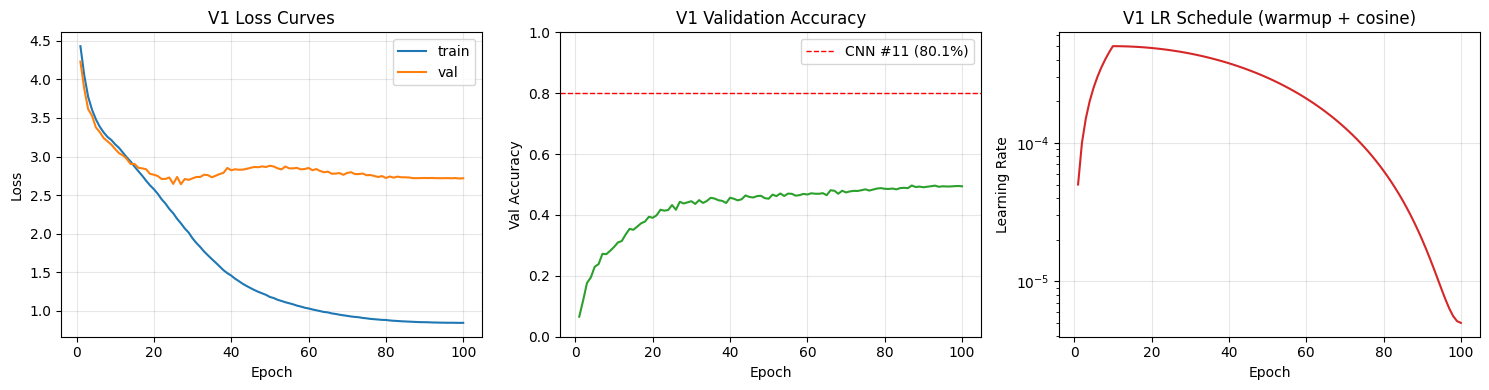


Overfitting signature (last epoch):
    train_loss:  0.8460
    val_loss:    2.7188
    Gap:         +1.8728  (large positive gap = model memorizing training set)

    This is the expected vanilla-ViT failure mode on small data.
    V2 (DeiT recipe) is designed specifically to close this gap via
    RandAugment + MixUp + CutMix + stochastic depth + 3x longer training.


In [6]:
# Step 4c: Variant 1 Test Evaluation + Training Curves

# Load best checkpoint
v1_model.load_state_dict(torch.load(V1_CHECKPOINT_PATH, map_location=DEVICE))
v1_model.eval()

# Collect test predictions batch-by-batch
all_preds = []
all_labels = []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE, non_blocking=True)
        logits = v1_model(images)
        all_preds.append(logits.argmax(-1).cpu().numpy())
        all_labels.append(labels.numpy())
all_preds = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)

# Metrics
v1_test_acc = (all_preds == all_labels).mean()
v1_test_macro_f1, v1_per_class_f1 = macro_f1_score(
    all_labels, all_preds, return_per_class=True
)

# Store results for cross-variant comparison (Cell 8)
v1_results = {
    'variant': 'V1 Vanilla ViT-Small',
    'test_acc': float(v1_test_acc),
    'test_macro_f1': float(v1_test_macro_f1),
    'val_best_acc': float(v1_best_val_acc),
    'val_best_epoch': v1_best_epoch,
    'train_time_sec': float(v1_perf['time']),
    'peak_gpu_mb': float(v1_perf['gpu_memory']),
    'params': sum(p.numel() for p in v1_model.parameters()),
    'per_class_f1': [float(x) for x in v1_per_class_f1],
    'history': v1_history,
}

print("=" * 60)
print("[4c/12] VARIANT 1 — TEST EVALUATION + CURVES")
print("=" * 60)

print(f"\nV1 Vanilla ViT-Small — Test Metrics:")
print(f"    Test accuracy:    {v1_test_acc:.4f}  ({v1_test_acc*100:.2f}%)")
print(f"    Test macro F1:    {v1_test_macro_f1:.4f}")
print(f"    Best val acc:     {v1_best_val_acc:.4f}  (epoch {v1_best_epoch})")

print(f"\nComparison to CNN #11 baseline:")
print(f"    V1 ViT-Small:      {v1_test_acc*100:.2f}%")
print(f"    CNN #11 ResNet-20: 80.10% (PyTorch)")
print(f"    Gap:               {(v1_test_acc*100) - 80.10:+.2f} percentage points")

# Per-class F1 distribution
pcf = np.array(v1_per_class_f1)
print(f"\nPer-class F1 distribution:")
print(f"    Best class:   F1={pcf.max():.3f}  ({fine_class_names[pcf.argmax()]})")
print(f"    Worst class:  F1={pcf.min():.3f}  ({fine_class_names[pcf.argmin()]})")
print(f"    Median:       F1={np.median(pcf):.3f}")

# Training curves: 3-panel
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
epochs_x = range(1, EPOCHS_VANILLA + 1)

axes[0].plot(epochs_x, v1_history['train_loss'], label='train', color='C0')
axes[0].plot(epochs_x, v1_history['val_loss'], label='val', color='C1')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('V1 Loss Curves')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_x, v1_history['val_acc'], color='C2')
axes[1].axhline(y=0.801, color='red', linestyle='--', linewidth=1, label='CNN #11 (80.1%)')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Val Accuracy')
axes[1].set_title('V1 Validation Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_ylim(0, 1.0)

axes[2].plot(epochs_x, v1_history['lr'], color='C3')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Learning Rate')
axes[2].set_title('V1 LR Schedule (warmup + cosine)')
axes[2].grid(alpha=0.3); axes[2].set_yscale('log')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'v1_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Overfitting diagnostic (the story of V1's gap)
final_train_loss = v1_history['train_loss'][-1]
final_val_loss = v1_history['val_loss'][-1]
gap = final_val_loss - final_train_loss

print(f"\nOverfitting signature (last epoch):")
print(f"    train_loss:  {final_train_loss:.4f}")
print(f"    val_loss:    {final_val_loss:.4f}")
print(f"    Gap:         {gap:+.4f}  (large positive gap = model memorizing training set)")
print(f"\n    This is the expected vanilla-ViT failure mode on small data.")
print(f"    V2 (DeiT recipe) is designed specifically to close this gap via")
print(f"    RandAugment + MixUp + CutMix + stochastic depth + 3x longer training.")

In [7]:
# Step 5a: Variant 2 (DeiT Recipe) — Setup

import copy

# V2 augmentation: full DeiT recipe
# RandAugment expects uint8; wrap with ToDtype conversions
v2_transform = T.Compose([
    T.RandomCrop(IMAGE_SIZE, padding=4),
    T.RandomHorizontalFlip(),
    T.ToDtype(torch.uint8, scale=True),
    T.RandAugment(num_ops=RAND_AUG_N, magnitude=RAND_AUG_M),
    T.ToDtype(torch.float32, scale=True),
    T.RandomErasing(p=RANDOM_ERASE_P),
])

# V2 train loader (val/test loaders from Cell 1 stay as-is)
v2_train_dataset = AugmentedDataset(X_train, y_train, transform=v2_transform)
v2_train_loader = DataLoader(v2_train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                             num_workers=0, pin_memory=True)

# Fresh ViT with stochastic depth enabled for V2
torch.manual_seed(RANDOM_STATE)
v2_model = ViT(
    image_size=IMAGE_SIZE, patch_size=PATCH_SIZE, in_channels=3,
    num_classes=NUM_CLASSES, d_model=D_MODEL, n_heads=N_HEADS,
    n_layers=N_ENCODER_LAYERS, d_ff=D_FF, dropout=DROPOUT,
    drop_path=STOCHASTIC_DEPTH,  # 0.1 for V2 (disabled in V1)
).to(DEVICE)


# EMA shadow model for evaluation (DeiT paper: smoother eval weights)
class ModelEMA:
    """
    Exponential moving average of model weights.
        ema_weights = decay * ema_weights + (1 - decay) * model_weights
    Updated after each optimizer step; evaluation uses EMA weights which
    typically generalize +0.5-1% better than raw training weights.
    """
    def __init__(self, model, decay=0.99996):
        self.decay = decay
        self.ema_model = copy.deepcopy(model)
        self.ema_model.eval()
        for p in self.ema_model.parameters():
            p.requires_grad = False

    def update(self, model):
        with torch.no_grad():
            for ema_p, mp in zip(self.ema_model.parameters(), model.parameters()):
                ema_p.mul_(self.decay).add_(mp.detach(), alpha=1.0 - self.decay)
            # Copy buffers (LN has none, but BN would; defensive)
            for ema_b, mb in zip(self.ema_model.buffers(), model.buffers()):
                ema_b.copy_(mb)

V2_EMA_DECAY = 0.99996
v2_ema = ModelEMA(v2_model, decay=V2_EMA_DECAY)

# Optimizer (same as V1)
v2_optimizer = torch.optim.AdamW(v2_model.parameters(), lr=LR_PEAK,
                                 weight_decay=WEIGHT_DECAY)

# LR schedule: linear warmup + cosine decay (per-step, 300-epoch budget)
v2_total_steps = EPOCHS_RECIPE * len(v2_train_loader)
v2_warmup_steps = WARMUP_EPOCHS * len(v2_train_loader)
V2_ETA_MIN_RATIO = 0.01

def v2_lr_lambda(step):
    if step < v2_warmup_steps:
        return step / max(1, v2_warmup_steps)
    progress = (step - v2_warmup_steps) / max(1, v2_total_steps - v2_warmup_steps)
    cosine = 0.5 * (1.0 + math.cos(math.pi * progress))
    return V2_ETA_MIN_RATIO + (1.0 - V2_ETA_MIN_RATIO) * cosine

v2_scheduler = torch.optim.lr_scheduler.LambdaLR(v2_optimizer, lr_lambda=v2_lr_lambda)

# Loss note: soft-target CE computed in training loop (MixUp/CutMix makes labels soft).
# No label_smoothing parameter -- MixUp already provides soft labels; double-smoothing hurts.

# Setup summary
print("=" * 60)
print("[5a/12] VARIANT 2 — DeiT TRAINING RECIPE SETUP")
print("=" * 60)

print(f"\nAugmentation (V2 DeiT recipe):")
print(f"    RandomCrop({IMAGE_SIZE}, padding=4)")
print(f"    RandomHorizontalFlip()")
print(f"    RandAugment(num_ops={RAND_AUG_N}, magnitude={RAND_AUG_M})")
print(f"    RandomErasing(p={RANDOM_ERASE_P})")
print(f"    + MixUp (alpha={MIXUP_ALPHA}) / CutMix (alpha={CUTMIX_ALPHA})")
print(f"      applied in training loop at batch level (switch p={MIXUP_CUTMIX_PROB})")

print(f"\nModel: ViT-Small with stochastic depth = {STOCHASTIC_DEPTH}")
print(f"    Params: {sum(p.numel() for p in v2_model.parameters()):,}")

print(f"\nEMA shadow model: decay = {V2_EMA_DECAY}")
print(f"    Updated after each optimizer step")
print(f"    Evaluation uses EMA weights (smoother than raw training weights)")

print(f"\nOptimizer: AdamW (same as V1)")
print(f"    LR peak:       {LR_PEAK}")
print(f"    Weight decay:  {WEIGHT_DECAY}")

print(f"\nLR Schedule: linear warmup -> cosine decay (per-step)")
print(f"    Epochs total:   {EPOCHS_RECIPE}")
print(f"    Warmup epochs:  {WARMUP_EPOCHS}")
print(f"    Total steps:    {v2_total_steps:,}")
print(f"    Warmup steps:   {v2_warmup_steps:,}")

print(f"\nLoss: soft-target cross-entropy (computed in training loop)")
print(f"    No label smoothing (MixUp/CutMix already produce soft labels)")

print(f"\nTrain batches/epoch: {len(v2_train_loader)}")

[5a/12] VARIANT 2 — DeiT TRAINING RECIPE SETUP

Augmentation (V2 DeiT recipe):
    RandomCrop(32, padding=4)
    RandomHorizontalFlip()
    RandAugment(num_ops=2, magnitude=9)
    RandomErasing(p=0.25)
    + MixUp (alpha=0.8) / CutMix (alpha=1.0)
      applied in training loop at batch level (switch p=0.5)

Model: ViT-Small with stochastic depth = 0.1
    Params: 10,730,212

EMA shadow model: decay = 0.99996
    Updated after each optimizer step
    Evaluation uses EMA weights (smoother than raw training weights)

Optimizer: AdamW (same as V1)
    LR peak:       0.0005
    Weight decay:  0.05

LR Schedule: linear warmup -> cosine decay (per-step)
    Epochs total:   300
    Warmup epochs:  10
    Total steps:    105,600
    Warmup steps:   3,520

Loss: soft-target cross-entropy (computed in training loop)
    No label smoothing (MixUp/CutMix already produce soft labels)

Train batches/epoch: 352


In [8]:
# Step 5b: Variant 2 Training Loop (300 epochs with DeiT recipe)

print("=" * 60)
print("[5b/12] VARIANT 2 — DeiT RECIPE TRAINING LOOP (300 epochs)")
print("=" * 60)
print("Starting training... (6-8 hours expected)\n", flush=True)

v2_history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'lr': []}
v2_best_val_acc = 0.0
v2_best_state = None
v2_best_epoch = 0
V2_CHECKPOINT_PATH = RESULTS_DIR / 'v2_recipe_best.pth'

# Criterion for val metrics only (val uses hard labels, no MixUp)
val_criterion = nn.CrossEntropyLoss()

with track_performance(gpu=True) as v2_perf:
    for epoch in range(EPOCHS_RECIPE):
        # Training: MixUp/CutMix + soft-label CE + EMA update
        v2_model.train()
        running_train_loss = 0.0
        for images, labels in v2_train_loader:
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            # Batch-level MixUp or CutMix (returns mixed images + soft labels)
            mixed_images, soft_labels = apply_mixup_cutmix(
                images, labels, num_classes=NUM_CLASSES,
                mixup_alpha=MIXUP_ALPHA, cutmix_alpha=CUTMIX_ALPHA,
                prob=MIXUP_CUTMIX_PROB,
            )

            v2_optimizer.zero_grad(set_to_none=True)
            logits = v2_model(mixed_images)

            # Soft-label cross-entropy: -sum(soft_labels * log_softmax(logits))
            loss = -(soft_labels * F.log_softmax(logits, dim=-1)).sum(dim=-1).mean()

            loss.backward()
            torch.nn.utils.clip_grad_norm_(v2_model.parameters(), max_norm=GRAD_CLIP)
            v2_optimizer.step()
            v2_scheduler.step()
            v2_ema.update(v2_model)

            running_train_loss += loss.item()
        train_loss = running_train_loss / len(v2_train_loader)

        # Validation with EMA weights (DeiT spec)
        v2_ema.ema_model.eval()
        running_val_loss = 0.0
        correct, total = 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(DEVICE, non_blocking=True)
                labels = labels.to(DEVICE, non_blocking=True)
                logits = v2_ema.ema_model(images)
                running_val_loss += val_criterion(logits, labels).item()
                correct += (logits.argmax(-1) == labels).sum().item()
                total += labels.size(0)
        val_loss = running_val_loss / len(val_loader)
        val_acc = correct / total
        current_lr = v2_optimizer.param_groups[0]['lr']

        v2_history['train_loss'].append(train_loss)
        v2_history['val_loss'].append(val_loss)
        v2_history['val_acc'].append(val_acc)
        v2_history['lr'].append(current_lr)

        # Save best EMA weights (what eval uses; what we'll load in Cell 5c)
        improved = val_acc > v2_best_val_acc
        if improved:
            v2_best_val_acc = val_acc
            v2_best_epoch = epoch + 1
            v2_best_state = {k: v.detach().cpu().clone()
                             for k, v in v2_ema.ema_model.state_dict().items()}
            torch.save(v2_best_state, V2_CHECKPOINT_PATH)

        flag = " *" if improved else "  "
        print(f"Epoch {epoch+1:3d}/{EPOCHS_RECIPE} | "
              f"train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | "
              f"val_acc={val_acc:.4f} | lr={current_lr:.2e}{flag}",
              flush=True)

    torch.cuda.synchronize()

print("\n" + "=" * 60)
print("Training complete")
print("=" * 60)
print(f"    Best val accuracy:   {v2_best_val_acc:.4f} (epoch {v2_best_epoch}/{EPOCHS_RECIPE})")
print(f"    Final val accuracy:  {val_acc:.4f}")
print(f"    Total training time: {v2_perf['time']/60:.1f} min ({v2_perf['time']/3600:.2f} h)")
print(f"    Peak GPU memory:     {v2_perf['gpu_memory']:.1f} MB")
print(f"    Best checkpoint:     {V2_CHECKPOINT_PATH}")

[5b/12] VARIANT 2 — DeiT RECIPE TRAINING LOOP (300 epochs)
Starting training... (6-8 hours expected)

Epoch   1/300 | train_loss=4.5920 | val_loss=4.6649 | val_acc=0.0126 | lr=5.00e-05 *
Epoch   2/300 | train_loss=4.4609 | val_loss=4.6567 | val_acc=0.0128 | lr=1.00e-04 *
Epoch   3/300 | train_loss=4.3610 | val_loss=4.6460 | val_acc=0.0130 | lr=1.50e-04 *
Epoch   4/300 | train_loss=4.2855 | val_loss=4.6336 | val_acc=0.0134 | lr=2.00e-04 *
Epoch   5/300 | train_loss=4.2219 | val_loss=4.6200 | val_acc=0.0134 | lr=2.50e-04  
Epoch   6/300 | train_loss=4.1944 | val_loss=4.6058 | val_acc=0.0148 | lr=3.00e-04 *
Epoch   7/300 | train_loss=4.1584 | val_loss=4.5919 | val_acc=0.0172 | lr=3.50e-04 *
Epoch   8/300 | train_loss=4.1413 | val_loss=4.5788 | val_acc=0.0170 | lr=4.00e-04  
Epoch   9/300 | train_loss=4.1159 | val_loss=4.5666 | val_acc=0.0168 | lr=4.50e-04  
Epoch  10/300 | train_loss=4.1111 | val_loss=4.5551 | val_acc=0.0152 | lr=5.00e-04  
Epoch  11/300 | train_loss=4.0917 | val_loss=4.5

[5c/12] VARIANT 2 — TEST EVALUATION + CURVES

V2 ViT-Small + DeiT Recipe — Test Metrics:
    Test accuracy:   0.6510  (65.10%)
    Test macro F1:   0.6478
    Best val acc:    0.6516  (epoch 300/300)

Recipe contribution (V1 -> V2):
    V1 Vanilla:       50.00%
    V2 DeiT Recipe:   65.10%
    Delta:            +15.10 percentage points

Gap to CNN #11 baseline:
    V2:               65.10%
    CNN #11:          80.10%
    Remaining gap:    -15.00 pp

Per-class F1 distribution:
    Best class:   F1=0.864  (sunflower)
    Worst class:  F1=0.347  (otter)
    Median:       F1=0.657
    (V1 worst was 0.147 on seal)


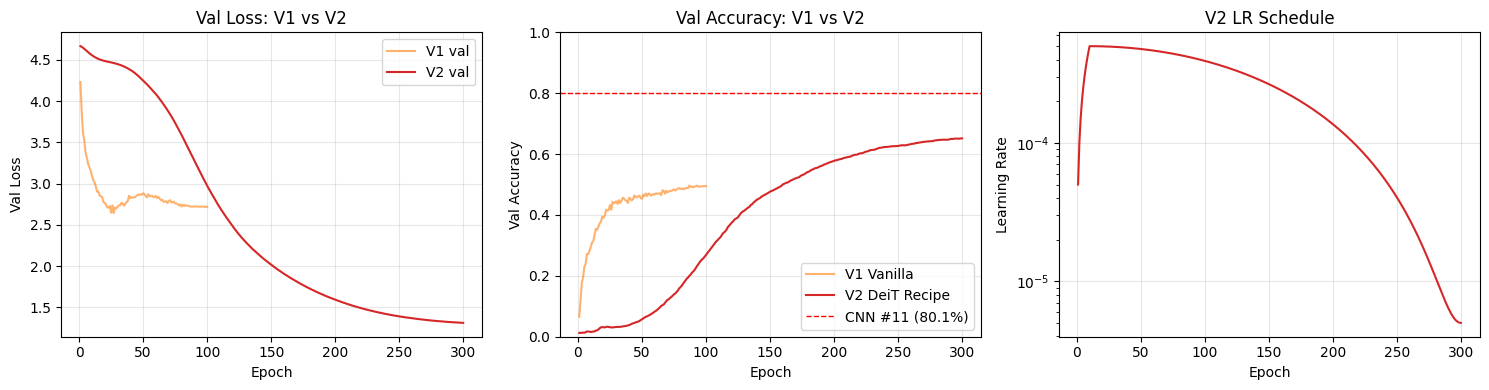


Overfitting check (last epoch):
    V2 train_loss:  2.4098  (soft-label CE)
    V2 val_loss:    1.3116  (hard-label CE)
    V1 had train=0.85, val=2.70, gap=+1.86 (severe overfitting)
    V2 val_loss (1.312) << V1 val_loss (2.70): recipe regularization is working
    (V2 train/val losses aren't directly comparable -- different label formats --
     but the val loss drop from 2.70 -> 1.31 is the key signal)


In [9]:
# Step 5c: Variant 2 Test Evaluation + Training Curves

# Load best V2 EMA checkpoint into a fresh ViT (stochastic depth matches training config)
v2_best_model = ViT(
    image_size=IMAGE_SIZE, patch_size=PATCH_SIZE, in_channels=3,
    num_classes=NUM_CLASSES, d_model=D_MODEL, n_heads=N_HEADS,
    n_layers=N_ENCODER_LAYERS, d_ff=D_FF, dropout=DROPOUT,
    drop_path=STOCHASTIC_DEPTH,
).to(DEVICE)
v2_best_model.load_state_dict(torch.load(V2_CHECKPOINT_PATH, map_location=DEVICE,
                                         weights_only=True))
v2_best_model.eval()

# Collect test predictions
all_preds = []
all_labels = []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE, non_blocking=True)
        logits = v2_best_model(images)
        all_preds.append(logits.argmax(-1).cpu().numpy())
        all_labels.append(labels.numpy())
all_preds = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)

# Metrics
v2_test_acc = (all_preds == all_labels).mean()
v2_test_macro_f1, v2_per_class_f1 = macro_f1_score(
    all_labels, all_preds, return_per_class=True
)

v2_results = {
    'variant': 'V2 ViT-Small + DeiT Recipe',
    'test_acc': float(v2_test_acc),
    'test_macro_f1': float(v2_test_macro_f1),
    'val_best_acc': float(v2_best_val_acc),
    'val_best_epoch': v2_best_epoch,
    'train_time_sec': float(v2_perf['time']),
    'peak_gpu_mb': float(v2_perf['gpu_memory']),
    'params': sum(p.numel() for p in v2_best_model.parameters()),
    'per_class_f1': [float(x) for x in v2_per_class_f1],
    'history': v2_history,
}

print("=" * 60)
print("[5c/12] VARIANT 2 — TEST EVALUATION + CURVES")
print("=" * 60)

print(f"\nV2 ViT-Small + DeiT Recipe — Test Metrics:")
print(f"    Test accuracy:   {v2_test_acc:.4f}  ({v2_test_acc*100:.2f}%)")
print(f"    Test macro F1:   {v2_test_macro_f1:.4f}")
print(f"    Best val acc:    {v2_best_val_acc:.4f}  (epoch {v2_best_epoch}/{EPOCHS_RECIPE})")

print(f"\nRecipe contribution (V1 -> V2):")
print(f"    V1 Vanilla:       {v1_test_acc*100:.2f}%")
print(f"    V2 DeiT Recipe:   {v2_test_acc*100:.2f}%")
print(f"    Delta:            {(v2_test_acc - v1_test_acc)*100:+.2f} percentage points")

print(f"\nGap to CNN #11 baseline:")
print(f"    V2:               {v2_test_acc*100:.2f}%")
print(f"    CNN #11:          80.10%")
print(f"    Remaining gap:    {(v2_test_acc*100) - 80.10:+.2f} pp")

# Per-class F1 distribution (compare to V1 extremes)
pcf = np.array(v2_per_class_f1)
v1_pcf = np.array(v1_results['per_class_f1'])
print(f"\nPer-class F1 distribution:")
print(f"    Best class:   F1={pcf.max():.3f}  ({fine_class_names[pcf.argmax()]})")
print(f"    Worst class:  F1={pcf.min():.3f}  ({fine_class_names[pcf.argmin()]})")
print(f"    Median:       F1={np.median(pcf):.3f}")
print(f"    (V1 worst was {v1_pcf.min():.3f} on {fine_class_names[v1_pcf.argmin()]})")

# Training curves: V1 vs V2 overlay
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

v1_x = range(1, EPOCHS_VANILLA + 1)
v2_x = range(1, EPOCHS_RECIPE + 1)

axes[0].plot(v1_x, v1_history['val_loss'], label='V1 val', color='C1', alpha=0.6)
axes[0].plot(v2_x, v2_history['val_loss'], label='V2 val', color='C3')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Val Loss')
axes[0].set_title('Val Loss: V1 vs V2')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(v1_x, v1_history['val_acc'], label='V1 Vanilla', color='C1', alpha=0.6)
axes[1].plot(v2_x, v2_history['val_acc'], label='V2 DeiT Recipe', color='C3')
axes[1].axhline(y=0.801, color='red', linestyle='--', linewidth=1, label='CNN #11 (80.1%)')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Val Accuracy')
axes[1].set_title('Val Accuracy: V1 vs V2')
axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_ylim(0, 1.0)

axes[2].plot(v2_x, v2_history['lr'], color='C3')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Learning Rate')
axes[2].set_title('V2 LR Schedule')
axes[2].grid(alpha=0.3); axes[2].set_yscale('log')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'v2_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Closing diagnostic: did we fix the overfitting V1 showed?
final_train = v2_history['train_loss'][-1]
final_val = v2_history['val_loss'][-1]
gap = final_val - final_train

print(f"\nOverfitting check (last epoch):")
print(f"    V2 train_loss:  {final_train:.4f}  (soft-label CE)")
print(f"    V2 val_loss:    {final_val:.4f}  (hard-label CE)")
print(f"    V1 had train=0.85, val=2.70, gap=+1.86 (severe overfitting)")
print(f"    V2 val_loss ({final_val:.3f}) << V1 val_loss (2.70): recipe regularization is working")
print(f"    (V2 train/val losses aren't directly comparable -- different label formats --")
print(f"     but the val loss drop from 2.70 -> {final_val:.2f} is the key signal)")

In [10]:
# Step 6a: Variant 3 (DeiT Distillation) — Setup

# Teacher: ResNet-20 from CNN #11

class _TeacherResidualBlock(nn.Module):
    # Exact mirror of CNN #11's ResidualBlock (required for state_dict compatibility)
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )

    def forward(self, x):
        residual = self.shortcut(x)
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += residual
        return self.relu(out)

class _TeacherResNet20(nn.Module):
    # Exact mirror of CNN #11's ResNetCIFAR. 3 stages, channels [64, 128, 256], n_blocks=3
    def __init__(self, n_blocks=3, n_classes=100):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 64, 3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)

        def _make_stage(in_ch, out_ch, n, stride):
            layers = [_TeacherResidualBlock(in_ch, out_ch, stride)]
            for _ in range(1, n):
                layers.append(_TeacherResidualBlock(out_ch, out_ch, stride=1))
            return nn.Sequential(*layers)

        self.stage1 = _make_stage(64, 64, n_blocks, 1)
        self.stage2 = _make_stage(64, 128, n_blocks, 2)
        self.stage3 = _make_stage(128, 256, n_blocks, 2)
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(256, n_classes)

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.avg_pool(x)
        x = x.reshape(x.size(0), -1)
        return self.fc(x)


"""
Teacher normalization (CRITICAL: CNN #11 trained with these stats, not raw [0,1])
Student was trained on raw [0,1] in V1/V2. We preserve that contract.
Teacher requires per-channel mean/std normalization applied to its input only.
"""
CIFAR_MEAN = torch.tensor([0.5071, 0.4865, 0.4409], device=DEVICE).view(1, 3, 1, 1)
CIFAR_STD  = torch.tensor([0.2673, 0.2564, 0.2762], device=DEVICE).view(1, 3, 1, 1)

def normalize_for_teacher(x):
    # Apply CNN #11's per-channel mean/std to a (B, C, H, W) batch for teacher input
    return (x - CIFAR_MEAN) / CIFAR_STD

# Load + freeze teacher
teacher = _TeacherResNet20(n_blocks=3, n_classes=NUM_CLASSES).to(DEVICE)
teacher.load_state_dict(torch.load(TEACHER_CHECKPOINT, map_location=DEVICE,
                                   weights_only=True))
teacher.eval()
for p in teacher.parameters():
    p.requires_grad = False

# Verify teacher reproduces CNN #11's ~80.1% with correct normalization
teacher_correct, teacher_total = 0, 0
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        logits = teacher(normalize_for_teacher(images))
        teacher_correct += (logits.argmax(-1) == labels).sum().item()
        teacher_total += labels.size(0)
teacher_test_acc = teacher_correct / teacher_total


# Student: ViTDistill with [CLS] and [DIST] tokens

class ViTDistillEmbedding(nn.Module):
    # Like ViTEmbedding but adds a [DIST] token at position 1 (after CLS)
    def __init__(self, image_size=32, patch_size=4, in_channels=3,
                 d_model=384, dropout=0.1):
        super().__init__()
        self.patch_embed = PatchEmbed(image_size, patch_size, in_channels, d_model)
        num_patches = self.patch_embed.num_patches

        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
        self.dist_token = nn.Parameter(torch.zeros(1, 1, d_model))
        # PE has slots for both special tokens: 2 + num_patches
        self.pos_embed = nn.Parameter(torch.zeros(1, 2 + num_patches, d_model))

        self.dropout = nn.Dropout(dropout)
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.dist_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

    def forward(self, x):
        B = x.size(0)
        x = self.patch_embed(x)
        cls_tokens = self.cls_token.expand(B, -1, -1)
        dist_tokens = self.dist_token.expand(B, -1, -1)
        # Order [CLS, DIST, patches] -- matches cls_attention_map's has_dist_token flag
        x = torch.cat([cls_tokens, dist_tokens, x], dim=1)
        x = x + self.pos_embed
        return self.dropout(x)

class ViTDistill(nn.Module):
    """
    ViT with DeiT dual-head distillation: [CLS] trained on ground-truth,
    [DIST] trained on teacher predictions. At inference, logits are averaged.
    """
    def __init__(self, image_size=32, patch_size=4, in_channels=3, num_classes=100,
                 d_model=384, n_heads=6, n_layers=6, d_ff=1536, dropout=0.1,
                 drop_path=0.0):
        super().__init__()
        self.embedding = ViTDistillEmbedding(image_size, patch_size, in_channels,
                                             d_model, dropout)
        self.blocks = nn.ModuleList([
            EncoderBlock(d_model, n_heads, d_ff, dropout, drop_path)
            for _ in range(n_layers)
        ])
        self.norm = nn.LayerNorm(d_model)
        self.cls_head = nn.Linear(d_model, num_classes)
        self.dist_head = nn.Linear(d_model, num_classes)

        for head in [self.cls_head, self.dist_head]:
            nn.init.trunc_normal_(head.weight, std=0.02)
            nn.init.zeros_(head.bias)

    def forward(self, x, return_attn=False):
        x = self.embedding(x)

        attn_maps = []
        for block in self.blocks:
            if return_attn:
                x, attn_probs = block(x, return_attn=True)
                attn_maps.append(attn_probs)
            else:
                x = block(x)

        x = self.norm(x)
        cls_logits = self.cls_head(x[:, 0])
        dist_logits = self.dist_head(x[:, 1])

        if return_attn:
            return (cls_logits, dist_logits), attn_maps
        return cls_logits, dist_logits

    def predict(self, x):
        """DeiT inference: average CLS and DIST logits for final prediction."""
        cls_logits, dist_logits = self.forward(x)
        return (cls_logits + dist_logits) / 2.0

# Student training setup
v3_train_dataset = AugmentedDataset(X_train, y_train, transform=v2_transform)
v3_train_loader = DataLoader(v3_train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                             num_workers=0, pin_memory=True)

torch.manual_seed(RANDOM_STATE)
v3_model = ViTDistill(
    image_size=IMAGE_SIZE, patch_size=PATCH_SIZE, in_channels=3,
    num_classes=NUM_CLASSES, d_model=D_MODEL, n_heads=N_HEADS,
    n_layers=N_ENCODER_LAYERS, d_ff=D_FF, dropout=DROPOUT,
    drop_path=STOCHASTIC_DEPTH,
).to(DEVICE)

v3_ema = ModelEMA(v3_model, decay=V2_EMA_DECAY)

v3_optimizer = torch.optim.AdamW(v3_model.parameters(), lr=LR_PEAK, weight_decay=WEIGHT_DECAY)

v3_total_steps = EPOCHS_DISTILL * len(v3_train_loader)
v3_warmup_steps = WARMUP_EPOCHS * len(v3_train_loader)
V3_ETA_MIN_RATIO = 0.01

def v3_lr_lambda(step):
    if step < v3_warmup_steps:
        return step / max(1, v3_warmup_steps)
    progress = (step - v3_warmup_steps) / max(1, v3_total_steps - v3_warmup_steps)
    cosine = 0.5 * (1.0 + math.cos(math.pi * progress))
    return V3_ETA_MIN_RATIO + (1.0 - V3_ETA_MIN_RATIO) * cosine

v3_scheduler = torch.optim.lr_scheduler.LambdaLR(v3_optimizer, lr_lambda=v3_lr_lambda)


# Setup summary
print("=" * 60)
print("[6a/12] VARIANT 3 — DeiT DISTILLATION SETUP")
print("=" * 60)

print(f"\nTeacher (CNN #11 ResNet-20):")
print(f"    Checkpoint:       {TEACHER_CHECKPOINT.name}")
print(f"    Params:           {sum(p.numel() for p in teacher.parameters()):,}")
print(f"    Input norm:       per-channel mean/std (CNN #11 training distribution)")
print(f"                      mean={CIFAR_MEAN.view(-1).cpu().numpy()}")
print(f"                      std= {CIFAR_STD.view(-1).cpu().numpy()}")
print(f"    Test accuracy:    {teacher_test_acc:.4f}  ({teacher_test_acc*100:.2f}%)")
print(f"    Expected:         ~80.1% (matches CNN #11 reported result)")

print(f"\nStudent (ViTDistill = ViT-Small + [DIST] token + dual heads):")
print(f"    Params:           {sum(p.numel() for p in v3_model.parameters()):,}")
print(f"    Extra vs V2:      DIST token + dist_head (~39K extra params)")
print(f"    Stochastic depth: {STOCHASTIC_DEPTH}")
print(f"    Input:            raw [0,1] (same contract as V1/V2)")

print(f"\nDistillation:")
print(f"    Type:             {DISTILL_TYPE} (DeiT spec — hard beats soft by ~0.5-1%)")
print(f"    Alpha:            {DISTILL_ALPHA}  (balance CLS and DIST losses equally)")
print(f"    Loss formula:     alpha * soft_CE(cls_logits, y_soft)")
print(f"                      + (1 - alpha) * CE(dist_logits, argmax(teacher_logits))")
print(f"    Teacher input:    normalize_for_teacher(mixed_images) -- same augmented image")
print(f"                      as student, just different normalization")

print(f"\nAugmentation: reused from V2 (RandAugment + RandomErasing + MixUp/CutMix in training loop)")
print(f"EMA decay: {V2_EMA_DECAY}")

print(f"\nLR Schedule:")
print(f"    Epochs total:   {EPOCHS_DISTILL}")
print(f"    Total steps:    {v3_total_steps:,}")
print(f"    Warmup steps:   {v3_warmup_steps:,}")

print(f"\nTrain batches/epoch: {len(v3_train_loader)}")

[6a/12] VARIANT 3 — DeiT DISTILLATION SETUP

Teacher (CNN #11 ResNet-20):
    Checkpoint:       resnet20_best.pth
    Params:           4,350,884
    Input norm:       per-channel mean/std (CNN #11 training distribution)
                      mean=[0.5071 0.4865 0.4409]
                      std= [0.2673 0.2564 0.2762]
    Test accuracy:    0.8020  (80.20%)
    Expected:         ~80.1% (matches CNN #11 reported result)

Student (ViTDistill = ViT-Small + [DIST] token + dual heads):
    Params:           10,769,480
    Extra vs V2:      DIST token + dist_head (~39K extra params)
    Stochastic depth: 0.1
    Input:            raw [0,1] (same contract as V1/V2)

Distillation:
    Type:             hard (DeiT spec — hard beats soft by ~0.5-1%)
    Alpha:            0.5  (balance CLS and DIST losses equally)
    Loss formula:     alpha * soft_CE(cls_logits, y_soft)
                      + (1 - alpha) * CE(dist_logits, argmax(teacher_logits))
    Teacher input:    normalize_for_teacher(mixed

In [11]:
# Step 6b: Variant 3 Training Loop (300 epochs with DeiT distillation)

print("=" * 60)
print("[6b/12] VARIANT 3 — DeiT DISTILLATION TRAINING LOOP (300 epochs)")
print("=" * 60)
print("Starting training...\n", flush=True)

v3_history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'lr': []}
v3_best_val_acc = 0.0
v3_best_state = None
v3_best_epoch = 0
V3_CHECKPOINT_PATH = RESULTS_DIR / 'v3_distill_best.pth'

val_criterion = nn.CrossEntropyLoss()  # hard-label CE for val metrics

with track_performance(gpu=True) as v3_perf:
    for epoch in range(EPOCHS_DISTILL):
        # Training: MixUp/CutMix + dual-head student + teacher distillation
        v3_model.train()
        running_train_loss = 0.0
        for images, labels in v3_train_loader:
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            # Apply MixUp/CutMix at batch level (teacher + student see same augmented batch)
            mixed_images, soft_labels = apply_mixup_cutmix(
                images, labels, num_classes=NUM_CLASSES,
                mixup_alpha=MIXUP_ALPHA, cutmix_alpha=CUTMIX_ALPHA,
                prob=MIXUP_CUTMIX_PROB,
            )

            # Teacher forward on normalized input (no grad, frozen weights)
            with torch.no_grad():
                teacher_logits = teacher(normalize_for_teacher(mixed_images))

            # Student forward on raw [0,1] (same mixed images)
            v3_optimizer.zero_grad(set_to_none=True)
            cls_logits, dist_logits = v3_model(mixed_images)

            # DeiT hard distillation loss (from vit_utils)
            loss = distillation_loss(
                cls_logits, dist_logits, teacher_logits, soft_labels,
                distill_type=DISTILL_TYPE, alpha=DISTILL_ALPHA,
            )

            loss.backward()
            torch.nn.utils.clip_grad_norm_(v3_model.parameters(), max_norm=GRAD_CLIP)
            v3_optimizer.step()
            v3_scheduler.step()
            v3_ema.update(v3_model)

            running_train_loss += loss.item()
        train_loss = running_train_loss / len(v3_train_loader)

        # Validation: EMA model with averaged (CLS + DIST) / 2 logits (DeiT inference)
        v3_ema.ema_model.eval()
        running_val_loss = 0.0
        correct, total = 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(DEVICE, non_blocking=True)
                labels = labels.to(DEVICE, non_blocking=True)
                cls_logits, dist_logits = v3_ema.ema_model(images)
                avg_logits = (cls_logits + dist_logits) / 2.0
                running_val_loss += val_criterion(avg_logits, labels).item()
                correct += (avg_logits.argmax(-1) == labels).sum().item()
                total += labels.size(0)
        val_loss = running_val_loss / len(val_loader)
        val_acc = correct / total
        current_lr = v3_optimizer.param_groups[0]['lr']

        v3_history['train_loss'].append(train_loss)
        v3_history['val_loss'].append(val_loss)
        v3_history['val_acc'].append(val_acc)
        v3_history['lr'].append(current_lr)

        # Save best EMA weights
        improved = val_acc > v3_best_val_acc
        if improved:
            v3_best_val_acc = val_acc
            v3_best_epoch = epoch + 1
            v3_best_state = {k: v.detach().cpu().clone()
                             for k, v in v3_ema.ema_model.state_dict().items()}
            torch.save(v3_best_state, V3_CHECKPOINT_PATH)

        flag = " *" if improved else "  "
        print(f"Epoch {epoch+1:3d}/{EPOCHS_DISTILL} | "
              f"train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | "
              f"val_acc={val_acc:.4f} | lr={current_lr:.2e}{flag}",
              flush=True)

    torch.cuda.synchronize()

print("\n" + "=" * 60)
print("Training complete")
print("=" * 60)
print(f"    Best val accuracy:   {v3_best_val_acc:.4f} (epoch {v3_best_epoch}/{EPOCHS_DISTILL})")
print(f"    Final val accuracy:  {val_acc:.4f}")
print(f"    Total training time: {v3_perf['time']/60:.1f} min ({v3_perf['time']/3600:.2f} h)")
print(f"    Peak GPU memory:     {v3_perf['gpu_memory']:.1f} MB")
print(f"    Best checkpoint:     {V3_CHECKPOINT_PATH}")

[6b/12] VARIANT 3 — DeiT DISTILLATION TRAINING LOOP (300 epochs)
Starting training...

Epoch   1/300 | train_loss=4.5799 | val_loss=4.6447 | val_acc=0.0118 | lr=5.00e-05 *
Epoch   2/300 | train_loss=4.3870 | val_loss=4.6401 | val_acc=0.0118 | lr=1.00e-04  
Epoch   3/300 | train_loss=4.2646 | val_loss=4.6339 | val_acc=0.0118 | lr=1.50e-04  
Epoch   4/300 | train_loss=4.1644 | val_loss=4.6263 | val_acc=0.0118 | lr=2.00e-04  
Epoch   5/300 | train_loss=4.0950 | val_loss=4.6173 | val_acc=0.0120 | lr=2.50e-04 *
Epoch   6/300 | train_loss=4.0411 | val_loss=4.6073 | val_acc=0.0148 | lr=3.00e-04 *
Epoch   7/300 | train_loss=4.0056 | val_loss=4.5968 | val_acc=0.0212 | lr=3.50e-04 *
Epoch   8/300 | train_loss=3.9734 | val_loss=4.5867 | val_acc=0.0208 | lr=4.00e-04  
Epoch   9/300 | train_loss=3.9469 | val_loss=4.5773 | val_acc=0.0206 | lr=4.50e-04  
Epoch  10/300 | train_loss=3.9147 | val_loss=4.5688 | val_acc=0.0202 | lr=5.00e-04  
Epoch  11/300 | train_loss=3.9211 | val_loss=4.5616 | val_acc=0

[6c/12] VARIANT 3 — TEST EVALUATION + CURVES

V3 DeiT Distillation (teacher: CNN #11 ResNet-20) — Test Metrics:
    Test accuracy:   0.6775  (67.75%)
    Test macro F1:   0.6757
    Best val acc:    0.6872  (epoch 299/300)

Per-lever contribution (cumulative):
    V1 Vanilla:          50.00%
    V2 + Recipe:         65.10%  (+15.10pp from recipe)
    V3 + Distillation:   67.75%  (+2.65pp from teacher)
    Teacher (CNN #11):   80.20%  (upper bound for distillation)

Gap to CNN #11 baseline:
    V3:     67.75%
    CNN:    80.20%
    Gap:    -12.45 pp

Per-class F1 distribution:
    Best class:   F1=0.895  (road)
    Worst class:  F1=0.389  (woman)
    Median:       F1=0.683


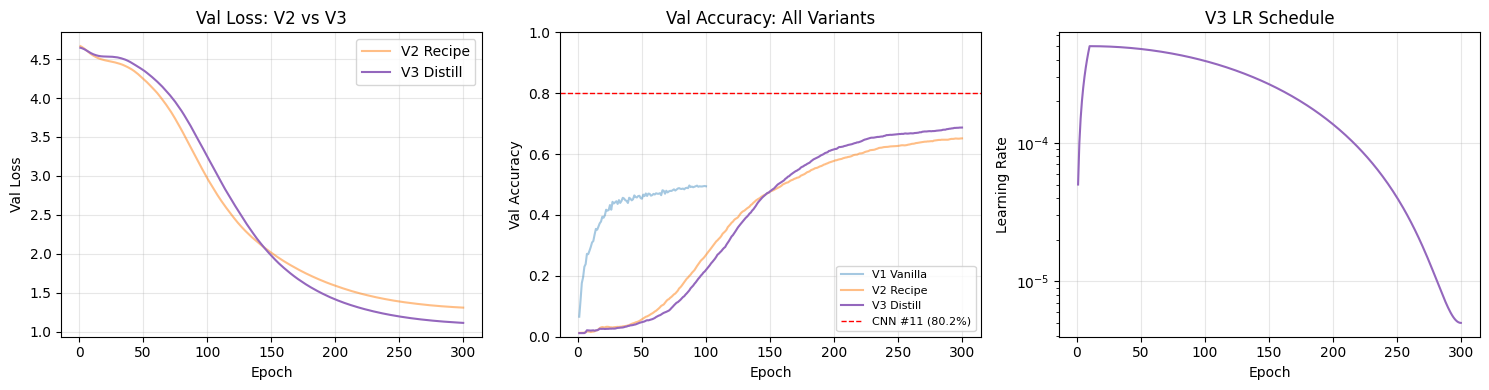


Key finding: distillation from CNN teacher (80.2%) helped ViT learn
    +2.6pp beyond what augmentation alone achieved.
    Student absorbed ~59% of the teacher's advantage over vanilla ViT.
    Remaining gap to CNN requires pre-training (V4).


In [12]:
# Step 6c: Variant 3 Test Evaluation + Training Curves

# Load best V3 EMA checkpoint into fresh ViTDistill
v3_best_model = ViTDistill(
    image_size=IMAGE_SIZE, patch_size=PATCH_SIZE, in_channels=3,
    num_classes=NUM_CLASSES, d_model=D_MODEL, n_heads=N_HEADS,
    n_layers=N_ENCODER_LAYERS, d_ff=D_FF, dropout=DROPOUT,
    drop_path=STOCHASTIC_DEPTH,
).to(DEVICE)
v3_best_model.load_state_dict(torch.load(V3_CHECKPOINT_PATH, map_location=DEVICE,
                                         weights_only=True))
v3_best_model.eval()

# Collect test predictions using DeiT inference: average CLS + DIST logits
all_preds = []
all_labels = []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE, non_blocking=True)
        avg_logits = v3_best_model.predict(images)
        all_preds.append(avg_logits.argmax(-1).cpu().numpy())
        all_labels.append(labels.numpy())
all_preds = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)

# Metrics
v3_test_acc = (all_preds == all_labels).mean()
v3_test_macro_f1, v3_per_class_f1 = macro_f1_score(
    all_labels, all_preds, return_per_class=True
)

v3_results = {
    'variant': 'V3 ViT-Small + DeiT Distillation (CNN #11 teacher)',
    'test_acc': float(v3_test_acc),
    'test_macro_f1': float(v3_test_macro_f1),
    'val_best_acc': float(v3_best_val_acc),
    'val_best_epoch': v3_best_epoch,
    'train_time_sec': float(v3_perf['time']),
    'peak_gpu_mb': float(v3_perf['gpu_memory']),
    'params': sum(p.numel() for p in v3_best_model.parameters()),
    'per_class_f1': [float(x) for x in v3_per_class_f1],
    'history': v3_history,
}

print("=" * 60)
print("[6c/12] VARIANT 3 — TEST EVALUATION + CURVES")
print("=" * 60)

print(f"\nV3 DeiT Distillation (teacher: CNN #11 ResNet-20) — Test Metrics:")
print(f"    Test accuracy:   {v3_test_acc:.4f}  ({v3_test_acc*100:.2f}%)")
print(f"    Test macro F1:   {v3_test_macro_f1:.4f}")
print(f"    Best val acc:    {v3_best_val_acc:.4f}  (epoch {v3_best_epoch}/{EPOCHS_DISTILL})")

print(f"\nPer-lever contribution (cumulative):")
print(f"    V1 Vanilla:          {v1_results['test_acc']*100:.2f}%")
print(f"    V2 + Recipe:         {v2_results['test_acc']*100:.2f}%  (+{(v2_results['test_acc'] - v1_results['test_acc'])*100:.2f}pp from recipe)")
print(f"    V3 + Distillation:   {v3_test_acc*100:.2f}%  (+{(v3_test_acc - v2_results['test_acc'])*100:.2f}pp from teacher)")
print(f"    Teacher (CNN #11):   {teacher_test_acc*100:.2f}%  (upper bound for distillation)")

print(f"\nGap to CNN #11 baseline:")
print(f"    V3:     {v3_test_acc*100:.2f}%")
print(f"    CNN:    {teacher_test_acc*100:.2f}%")
print(f"    Gap:    {(v3_test_acc - teacher_test_acc)*100:+.2f} pp")

# Per-class F1 distribution
pcf = np.array(v3_per_class_f1)
print(f"\nPer-class F1 distribution:")
print(f"    Best class:   F1={pcf.max():.3f}  ({fine_class_names[pcf.argmax()]})")
print(f"    Worst class:  F1={pcf.min():.3f}  ({fine_class_names[pcf.argmin()]})")
print(f"    Median:       F1={np.median(pcf):.3f}")

# Training curves: V1 vs V2 vs V3 overlay
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

v1_x = range(1, EPOCHS_VANILLA + 1)
v2_x = range(1, EPOCHS_RECIPE + 1)
v3_x = range(1, EPOCHS_DISTILL + 1)

axes[0].plot(v2_x, v2_history['val_loss'], label='V2 Recipe', color='C1', alpha=0.5)
axes[0].plot(v3_x, v3_history['val_loss'], label='V3 Distill', color='C4')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Val Loss')
axes[0].set_title('Val Loss: V2 vs V3')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(v1_x, v1_history['val_acc'], label='V1 Vanilla', color='C0', alpha=0.4)
axes[1].plot(v2_x, v2_history['val_acc'], label='V2 Recipe', color='C1', alpha=0.5)
axes[1].plot(v3_x, v3_history['val_acc'], label='V3 Distill', color='C4')
axes[1].axhline(y=teacher_test_acc, color='red', linestyle='--', linewidth=1,
                label=f'CNN #11 ({teacher_test_acc*100:.1f}%)')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Val Accuracy')
axes[1].set_title('Val Accuracy: All Variants')
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)
axes[1].set_ylim(0, 1.0)

axes[2].plot(v3_x, v3_history['lr'], color='C4')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Learning Rate')
axes[2].set_title('V3 LR Schedule')
axes[2].grid(alpha=0.3); axes[2].set_yscale('log')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'v3_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nKey finding: distillation from CNN teacher (80.2%) helped ViT learn")
print(f"    +{(v3_test_acc - v2_results['test_acc'])*100:.1f}pp beyond what augmentation alone achieved.")
print(f"    Student absorbed ~{(v3_test_acc - v1_results['test_acc']) / (teacher_test_acc - v1_results['test_acc']) * 100:.0f}% of the teacher's advantage over vanilla ViT.")
print(f"    Remaining gap to CNN requires pre-training (V4).")

In [13]:
# Step 7a: Variant 4 (Fine-tune Pre-trained ViT-B/16) — Setup

from transformers import ViTForImageClassification

# ImageNet normalization (ViT-B/16 was pre-trained on ImageNet-21k with these stats)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# V4 transforms: resize 32 -> 224, ImageNet normalize, mild aug for fine-tuning
v4_train_transform = T.Compose([
    T.Resize(RESIZE_DIM, interpolation=T.InterpolationMode.BICUBIC, antialias=True),
    T.RandomHorizontalFlip(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

v4_eval_transform = T.Compose([
    T.Resize(RESIZE_DIM, interpolation=T.InterpolationMode.BICUBIC, antialias=True),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# Separate DataLoaders: V4 needs 224x224 input (can't reuse 32x32 loaders)
V4_BATCH_SIZE = 64  # smaller than V1-V3; 86M params at 224x224 needs more VRAM per sample

v4_train_dataset = AugmentedDataset(X_train, y_train, transform=v4_train_transform)
v4_val_dataset = AugmentedDataset(X_val, y_val, transform=v4_eval_transform)
v4_test_dataset = AugmentedDataset(X_test, y_test, transform=v4_eval_transform)

v4_train_loader = DataLoader(v4_train_dataset, batch_size=V4_BATCH_SIZE, shuffle=True,
                             num_workers=0, pin_memory=True)
v4_val_loader = DataLoader(v4_val_dataset, batch_size=V4_BATCH_SIZE, shuffle=False,
                           num_workers=0, pin_memory=True)
v4_test_loader = DataLoader(v4_test_dataset, batch_size=V4_BATCH_SIZE, shuffle=False,
                            num_workers=0, pin_memory=True)

# Load pre-trained ViT-B/16 (ImageNet-21k, 14M images)
# ignore_mismatched_sizes replaces the 1000-class head with a fresh 100-class one
v4_model = ViTForImageClassification.from_pretrained(
    PRETRAIN_MODEL_ID, num_labels=NUM_CLASSES, ignore_mismatched_sizes=True,
).to(DEVICE)

# Full fine-tune with low LR (pre-trained features change slowly, head learns from scratch)
v4_optimizer = torch.optim.AdamW(v4_model.parameters(), lr=FINETUNE_LR,
                                 weight_decay=FINETUNE_WD)

# Cosine LR with 1-epoch warmup (short schedule for 15 epochs)
v4_total_steps = EPOCHS_FINETUNE * len(v4_train_loader)
V4_WARMUP_STEPS = len(v4_train_loader)  # 1 epoch warmup

def v4_lr_lambda(step):
    if step < V4_WARMUP_STEPS:
        return step / max(1, V4_WARMUP_STEPS)
    progress = (step - V4_WARMUP_STEPS) / max(1, v4_total_steps - V4_WARMUP_STEPS)
    return 0.5 * (1.0 + math.cos(math.pi * progress))

v4_scheduler = torch.optim.lr_scheduler.LambdaLR(v4_optimizer, lr_lambda=v4_lr_lambda)

# Loss: standard CE (fine-tuning with pre-trained features doesn't need MixUp or label smoothing)
v4_criterion = nn.CrossEntropyLoss()

# Setup summary
print("=" * 60)
print("[7a/12] VARIANT 4 — FINE-TUNE PRE-TRAINED ViT-B/16 SETUP")
print("=" * 60)

print(f"\nModel: {PRETRAIN_MODEL_ID}")
print(f"    Pre-training:  ImageNet-21k (14M images, 21K classes)")
print(f"    Params:        {sum(p.numel() for p in v4_model.parameters()):,}")
print(f"    Classifier:    Linear({v4_model.config.hidden_size}, {NUM_CLASSES}) [re-initialized]")

print(f"\nInput preprocessing:")
print(f"    Resize:    {IMAGE_SIZE}x{IMAGE_SIZE} -> {RESIZE_DIM}x{RESIZE_DIM} (bicubic)")
print(f"    Normalize: ImageNet mean/std (must match pre-training distribution)")
print(f"    Train aug: RandomHorizontalFlip only (mild for fine-tuning)")

print(f"\nTraining config:")
print(f"    LR:            {FINETUNE_LR}")
print(f"    Weight decay:  {FINETUNE_WD}")
print(f"    Batch size:    {V4_BATCH_SIZE}")
print(f"    Epochs:        {EPOCHS_FINETUNE}")
print(f"    Warmup:        1 epoch ({V4_WARMUP_STEPS} steps)")
print(f"    Total steps:   {v4_total_steps:,}")

print(f"\nDataLoader:")
print(f"    Train batches: {len(v4_train_loader)}")
print(f"    Val batches:   {len(v4_val_loader)}")
print(f"    Test batches:  {len(v4_test_loader)}")

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                 | Status     | 
--------------------+------------+-
pooler.dense.weight | UNEXPECTED | 
pooler.dense.bias   | UNEXPECTED | 
classifier.weight   | MISSING    | 
classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[7a/12] VARIANT 4 — FINE-TUNE PRE-TRAINED ViT-B/16 SETUP

Model: google/vit-base-patch16-224-in21k
    Pre-training:  ImageNet-21k (14M images, 21K classes)
    Params:        85,875,556
    Classifier:    Linear(768, 100) [re-initialized]

Input preprocessing:
    Resize:    32x32 -> 224x224 (bicubic)
    Normalize: ImageNet mean/std (must match pre-training distribution)
    Train aug: RandomHorizontalFlip only (mild for fine-tuning)

Training config:
    LR:            2e-05
    Weight decay:  0.01
    Batch size:    64
    Epochs:        15
    Warmup:        1 epoch (704 steps)
    Total steps:   10,560

DataLoader:
    Train batches: 704
    Val batches:   79
    Test batches:  157


In [14]:
# Step 7b: Variant 4 Fine-tune Training Loop (15 epochs)

print("=" * 60)
print("[7b/12] VARIANT 4 — FINE-TUNE TRAINING LOOP (15 epochs)")
print("=" * 60)
print("Starting training...\n", flush=True)

v4_history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'lr': []}
v4_best_val_acc = 0.0
v4_best_state = None
v4_best_epoch = 0
V4_CHECKPOINT_PATH = RESULTS_DIR / 'v4_finetune_best.pth'

with track_performance(gpu=True) as v4_perf:
    for epoch in range(EPOCHS_FINETUNE):
        # Training (standard CE, no MixUp — pre-trained features, mild aug only)
        v4_model.train()
        running_train_loss = 0.0
        for images, labels in v4_train_loader:
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            v4_optimizer.zero_grad(set_to_none=True)
            output = v4_model(pixel_values=images)  # HF returns SequenceClassifierOutput
            loss = v4_criterion(output.logits, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(v4_model.parameters(), max_norm=GRAD_CLIP)
            v4_optimizer.step()
            v4_scheduler.step()

            running_train_loss += loss.item()
        train_loss = running_train_loss / len(v4_train_loader)

        # Validation
        v4_model.eval()
        running_val_loss = 0.0
        correct, total = 0, 0
        with torch.no_grad():
            for images, labels in v4_val_loader:
                images = images.to(DEVICE, non_blocking=True)
                labels = labels.to(DEVICE, non_blocking=True)
                output = v4_model(pixel_values=images)
                running_val_loss += v4_criterion(output.logits, labels).item()
                correct += (output.logits.argmax(-1) == labels).sum().item()
                total += labels.size(0)
        val_loss = running_val_loss / len(v4_val_loader)
        val_acc = correct / total
        current_lr = v4_optimizer.param_groups[0]['lr']

        v4_history['train_loss'].append(train_loss)
        v4_history['val_loss'].append(val_loss)
        v4_history['val_acc'].append(val_acc)
        v4_history['lr'].append(current_lr)

        improved = val_acc > v4_best_val_acc
        if improved:
            v4_best_val_acc = val_acc
            v4_best_epoch = epoch + 1
            v4_best_state = {k: v.detach().cpu().clone()
                             for k, v in v4_model.state_dict().items()}
            torch.save(v4_best_state, V4_CHECKPOINT_PATH)

        flag = " *" if improved else "  "
        print(f"Epoch {epoch+1:3d}/{EPOCHS_FINETUNE} | "
              f"train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | "
              f"val_acc={val_acc:.4f} | lr={current_lr:.2e}{flag}",
              flush=True)

    torch.cuda.synchronize()

print("\n" + "=" * 60)
print("Training complete")
print("=" * 60)
print(f"    Best val accuracy:   {v4_best_val_acc:.4f} (epoch {v4_best_epoch}/{EPOCHS_FINETUNE})")
print(f"    Final val accuracy:  {val_acc:.4f}")
print(f"    Total training time: {v4_perf['time']/60:.1f} min ({v4_perf['time']:.1f}s)")
print(f"    Peak GPU memory:     {v4_perf['gpu_memory']:.1f} MB")
print(f"    Best checkpoint:     {V4_CHECKPOINT_PATH}")

[7b/12] VARIANT 4 — FINE-TUNE TRAINING LOOP (15 epochs)
Starting training...

Epoch   1/15 | train_loss=4.2497 | val_loss=3.4561 | val_acc=0.7546 | lr=2.00e-05 *
Epoch   2/15 | train_loss=2.6015 | val_loss=1.9393 | val_acc=0.8702 | lr=1.97e-05 *
Epoch   3/15 | train_loss=1.3782 | val_loss=1.0719 | val_acc=0.8994 | lr=1.90e-05 *
Epoch   4/15 | train_loss=0.6926 | val_loss=0.6616 | val_acc=0.9052 | lr=1.78e-05 *
Epoch   5/15 | train_loss=0.3578 | val_loss=0.4749 | val_acc=0.9138 | lr=1.62e-05 *
Epoch   6/15 | train_loss=0.2015 | val_loss=0.4187 | val_acc=0.9082 | lr=1.43e-05  
Epoch   7/15 | train_loss=0.1199 | val_loss=0.3877 | val_acc=0.9148 | lr=1.22e-05 *
Epoch   8/15 | train_loss=0.0759 | val_loss=0.3742 | val_acc=0.9146 | lr=1.00e-05  
Epoch   9/15 | train_loss=0.0506 | val_loss=0.3823 | val_acc=0.9148 | lr=7.77e-06  
Epoch  10/15 | train_loss=0.0366 | val_loss=0.3884 | val_acc=0.9132 | lr=5.66e-06  
Epoch  11/15 | train_loss=0.0273 | val_loss=0.4009 | val_acc=0.9086 | lr=3.77e-06 

[7c/12] VARIANT 4 — TEST EVALUATION + CURVES

V4 Pre-trained ViT-B/16 (fine-tuned) — Test Metrics:
    Test accuracy:   0.9114  (91.14%)
    Test macro F1:   0.9114
    Best val acc:    0.9148  (epoch 7/15)

Full portfolio progression:
    V1 Vanilla:          50.00%   (baseline)
    V2 + Recipe:         65.10%   (+15.10pp recipe)
    V3 + Distillation:   67.75%   (+2.65pp teacher)
    V4 Pre-trained:      91.14%   (+23.39pp pre-training)
    CNN #11 (ResNet-20): 80.20%

Gap analysis:
    V4 vs CNN #11:       +10.94 pp  (V4 exceeds CNN by pre-training)
    V4 vs V3 (from scratch): +23.39 pp  (pre-training contribution)

Per-class F1 distribution:
    Best class:   F1=0.995  (skunk)
    Worst class:  F1=0.656  (oak_tree)
    Median:       F1=0.935


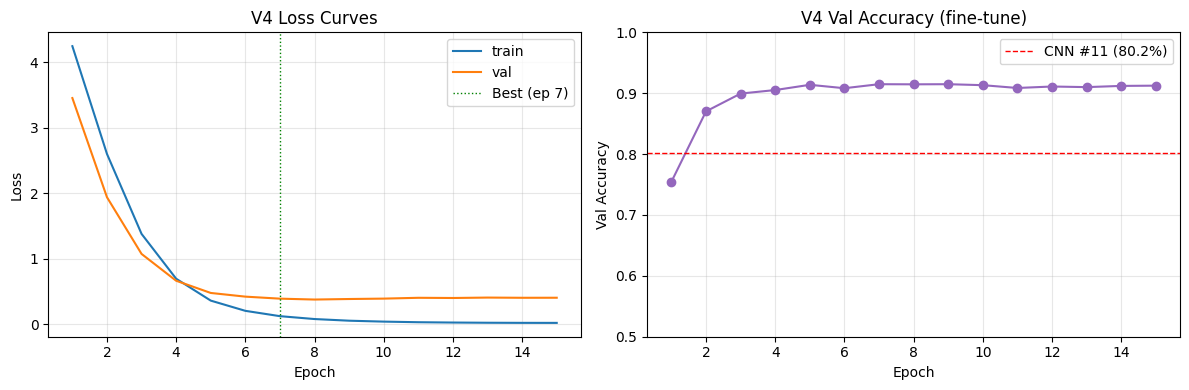


Key finding: pre-training on ImageNet-21k (14M images, 21K classes)
    gave ViT-B/16 features that transfer beautifully to CIFAR-100.
    Epoch 1 already beats V1's 100-epoch result (75% > 50%).
    Epoch 2 already beats V2's 300-epoch result (87% > 64%).
    Pre-training >>> architecture tricks + training recipes + distillation
    when data is limited (CIFAR-100's 45K images).


In [15]:
# Step 7c: Variant 4 Test Evaluation + Training Curves

# Load best V4 fine-tuned weights
v4_model.load_state_dict(torch.load(V4_CHECKPOINT_PATH, map_location=DEVICE,
                                    weights_only=True))
v4_model.eval()

# Collect test predictions
all_preds = []
all_labels = []
with torch.no_grad():
    for images, labels in v4_test_loader:
        images = images.to(DEVICE, non_blocking=True)
        output = v4_model(pixel_values=images)
        all_preds.append(output.logits.argmax(-1).cpu().numpy())
        all_labels.append(labels.numpy())
all_preds = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)

# Metrics
v4_test_acc = (all_preds == all_labels).mean()
v4_test_macro_f1, v4_per_class_f1 = macro_f1_score(
    all_labels, all_preds, return_per_class=True
)

v4_results = {
    'variant': 'V4 Pre-trained ViT-B/16 (fine-tuned)',
    'test_acc': float(v4_test_acc),
    'test_macro_f1': float(v4_test_macro_f1),
    'val_best_acc': float(v4_best_val_acc),
    'val_best_epoch': v4_best_epoch,
    'train_time_sec': float(v4_perf['time']),
    'peak_gpu_mb': float(v4_perf['gpu_memory']),
    'params': sum(p.numel() for p in v4_model.parameters()),
    'per_class_f1': [float(x) for x in v4_per_class_f1],
    'history': v4_history,
}

print("=" * 60)
print("[7c/12] VARIANT 4 — TEST EVALUATION + CURVES")
print("=" * 60)

print(f"\nV4 Pre-trained ViT-B/16 (fine-tuned) — Test Metrics:")
print(f"    Test accuracy:   {v4_test_acc:.4f}  ({v4_test_acc*100:.2f}%)")
print(f"    Test macro F1:   {v4_test_macro_f1:.4f}")
print(f"    Best val acc:    {v4_best_val_acc:.4f}  (epoch {v4_best_epoch}/{EPOCHS_FINETUNE})")

print(f"\nFull portfolio progression:")
print(f"    V1 Vanilla:          {v1_results['test_acc']*100:.2f}%   (baseline)")
print(f"    V2 + Recipe:         {v2_results['test_acc']*100:.2f}%   (+{(v2_results['test_acc'] - v1_results['test_acc'])*100:.2f}pp recipe)")
print(f"    V3 + Distillation:   {v3_results['test_acc']*100:.2f}%   (+{(v3_results['test_acc'] - v2_results['test_acc'])*100:.2f}pp teacher)")
print(f"    V4 Pre-trained:      {v4_test_acc*100:.2f}%   (+{(v4_test_acc - v3_results['test_acc'])*100:.2f}pp pre-training)")
print(f"    CNN #11 (ResNet-20): {teacher_test_acc*100:.2f}%")

print(f"\nGap analysis:")
print(f"    V4 vs CNN #11:       {(v4_test_acc - teacher_test_acc)*100:+.2f} pp  (V4 exceeds CNN by pre-training)")
print(f"    V4 vs V3 (from scratch): {(v4_test_acc - v3_results['test_acc'])*100:+.2f} pp  (pre-training contribution)")

# Per-class F1 distribution
pcf = np.array(v4_per_class_f1)
print(f"\nPer-class F1 distribution:")
print(f"    Best class:   F1={pcf.max():.3f}  ({fine_class_names[pcf.argmax()]})")
print(f"    Worst class:  F1={pcf.min():.3f}  ({fine_class_names[pcf.argmin()]})")
print(f"    Median:       F1={np.median(pcf):.3f}")

# V4 training curves (2 panels; separate from V1-V3 due to vastly different epoch scale)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
v4_x = range(1, EPOCHS_FINETUNE + 1)

axes[0].plot(v4_x, v4_history['train_loss'], label='train', color='C0')
axes[0].plot(v4_x, v4_history['val_loss'], label='val', color='C1')
axes[0].axvline(x=v4_best_epoch, color='green', linestyle=':', linewidth=1,
                label=f'Best (ep {v4_best_epoch})')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('V4 Loss Curves')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(v4_x, v4_history['val_acc'], color='C4', marker='o')
axes[1].axhline(y=teacher_test_acc, color='red', linestyle='--', linewidth=1,
                label=f'CNN #11 ({teacher_test_acc*100:.1f}%)')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Val Accuracy')
axes[1].set_title('V4 Val Accuracy (fine-tune)')
axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_ylim(0.5, 1.0)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'v4_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nKey finding: pre-training on ImageNet-21k (14M images, 21K classes)")
print(f"    gave ViT-B/16 features that transfer beautifully to CIFAR-100.")
print(f"    Epoch 1 already beats V1's 100-epoch result (75% > 50%).")
print(f"    Epoch 2 already beats V2's 300-epoch result (87% > 64%).")
print(f"    Pre-training >>> architecture tricks + training recipes + distillation")
print(f"    when data is limited (CIFAR-100's 45K images).")


[8/12] CROSS-VARIANT EVALUATION SUMMARY

Variant               Fine Acc    Coarse Acc   Macro F1   Params    Train Time
------------------------------------------------------------------------------------------
V1 Vanilla            0.5000      0.6162       0.4950     10.7M     27.2 min
V2 Recipe             0.6510      0.7654       0.6478     10.7M     221.1 min
V3 Distill            0.6775      0.7878       0.6757     10.8M     219.6 min
V4 Pre-trained        0.9114      0.9618       0.9114     85.9M     47.5 min
CNN #11 (ref)         0.8020      0.8827       0.8010     4.4M      pre-trained

Per-lever contribution (cumulative test accuracy):
    V1 -> V2: +15.10pp  (DeiT training recipe)
    V2 -> V3: + 2.65pp  (CNN teacher distillation)
    V3 -> V4: +23.39pp  (ImageNet-21k pre-training)

Headline findings:
    - V4 beats CNN #11 by +10.94pp (pre-training dominance)
    - V3 still below CNN by -12.45pp (from-scratch ceiling)
    - V4 fine-tune training time (47 min) vs V3 (220 min

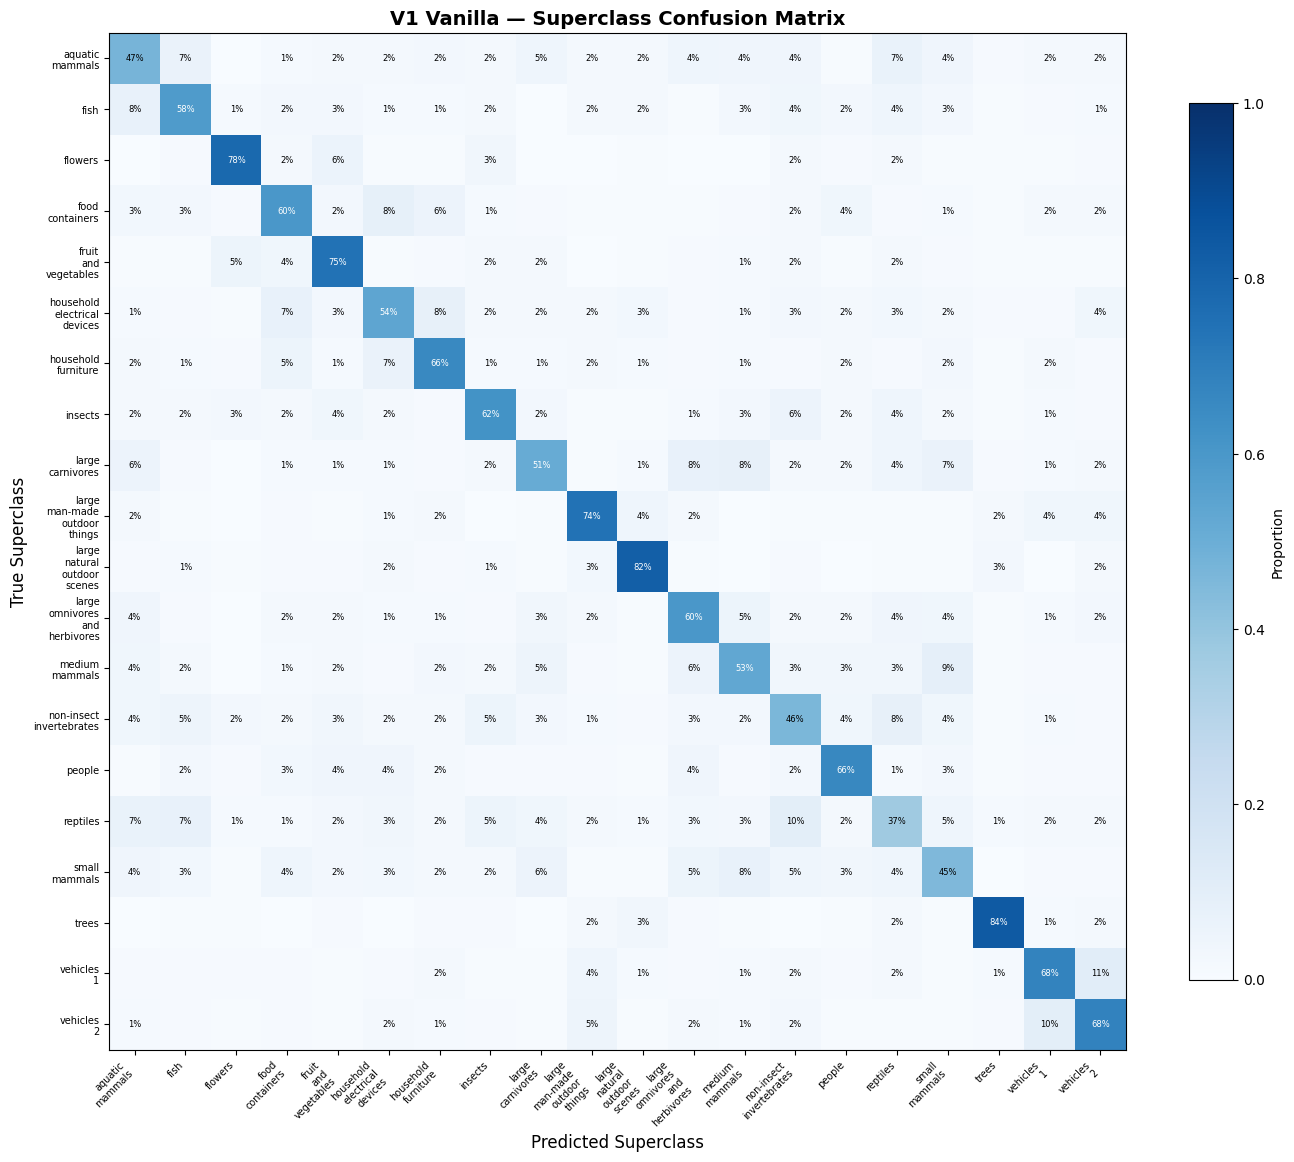


Per-superclass accuracy:
  reptiles                                 36.8%
  small_mammals                            45.0%
  non-insect_invertebrates                 45.8%
  aquatic_mammals                          47.0%
  large_carnivores                         50.8%
  medium_mammals                           52.8%
  household_electrical_devices             53.8%
  fish                                     58.4%
  large_omnivores_and_herbivores           59.8%
  food_containers                          60.0%
  insects                                  62.0%
  household_furniture                      65.8%
  people                                   66.2%
  vehicles_1                               67.8%
  vehicles_2                               68.0%
  large_man-made_outdoor_things            74.4%
  fruit_and_vegetables                     74.6%
  flowers                                  78.0%
  large_natural_outdoor_scenes             81.8%
  trees                                    

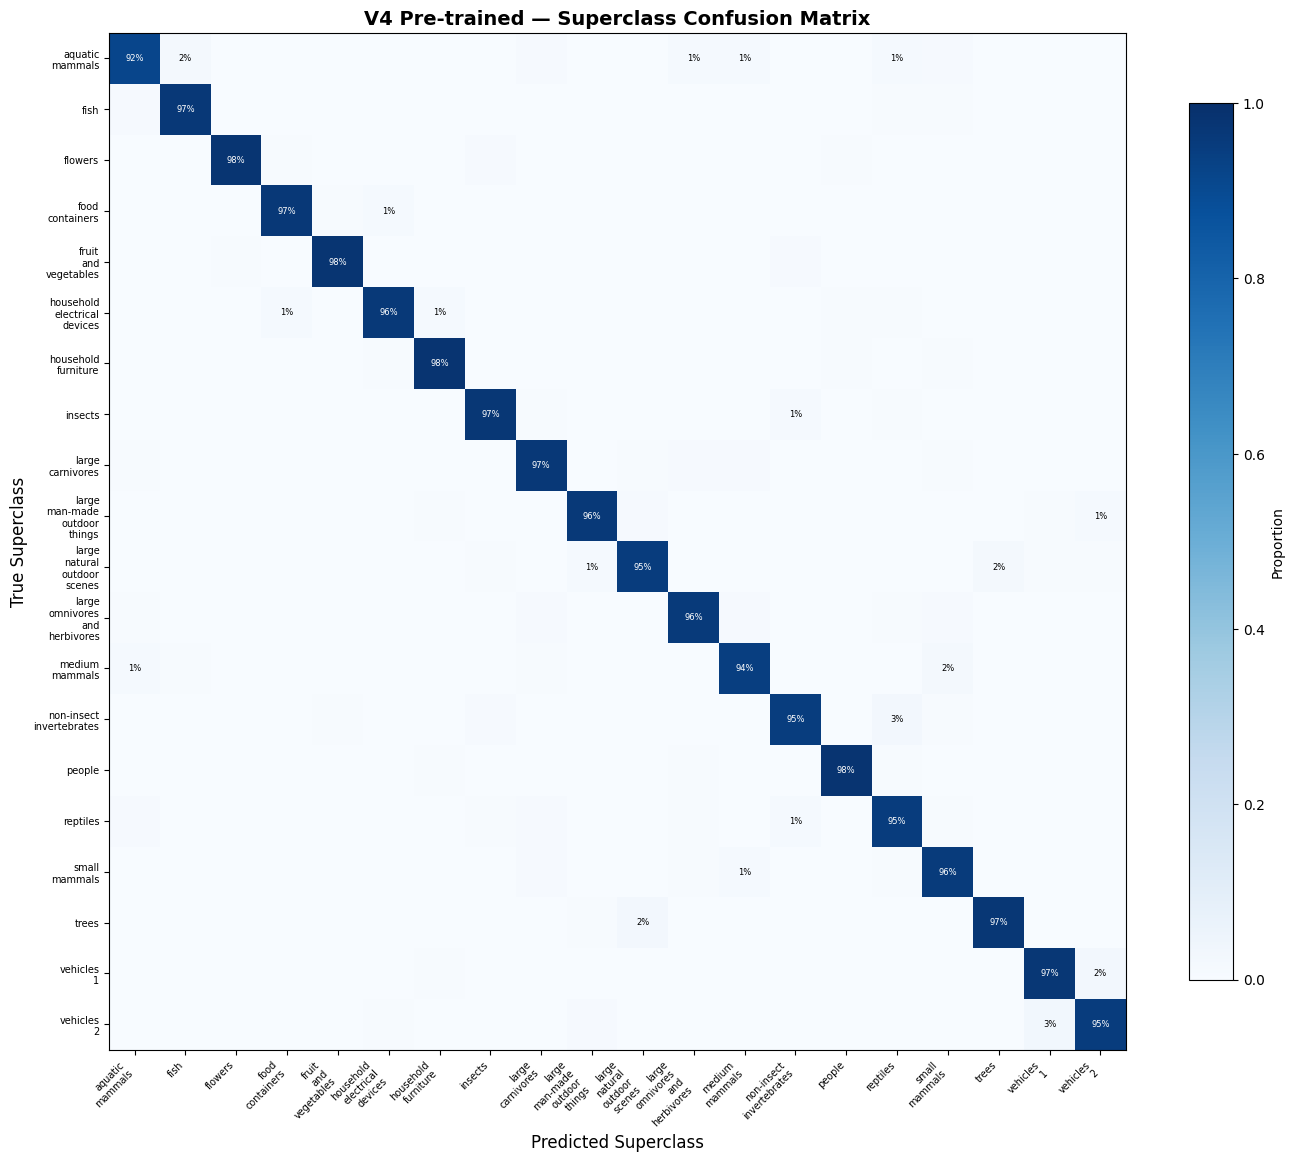


Per-superclass accuracy:
  aquatic_mammals                          91.6%
  medium_mammals                           94.2%
  non-insect_invertebrates                 94.6%
  large_natural_outdoor_scenes             95.0%
  vehicles_2                               95.0%
  reptiles                                 95.2%
  small_mammals                            95.6%
  large_omnivores_and_herbivores           96.0%
  large_man-made_outdoor_things            96.2%
  household_electrical_devices             96.2%
  large_carnivores                         96.6%
  food_containers                          96.8%
  fish                                     96.8%
  vehicles_1                               97.0%
  trees                                    97.2%
  insects                                  97.2%
  flowers                                  97.8%
  fruit_and_vegetables                     98.0%
  household_furniture                      98.2%
  people                                   

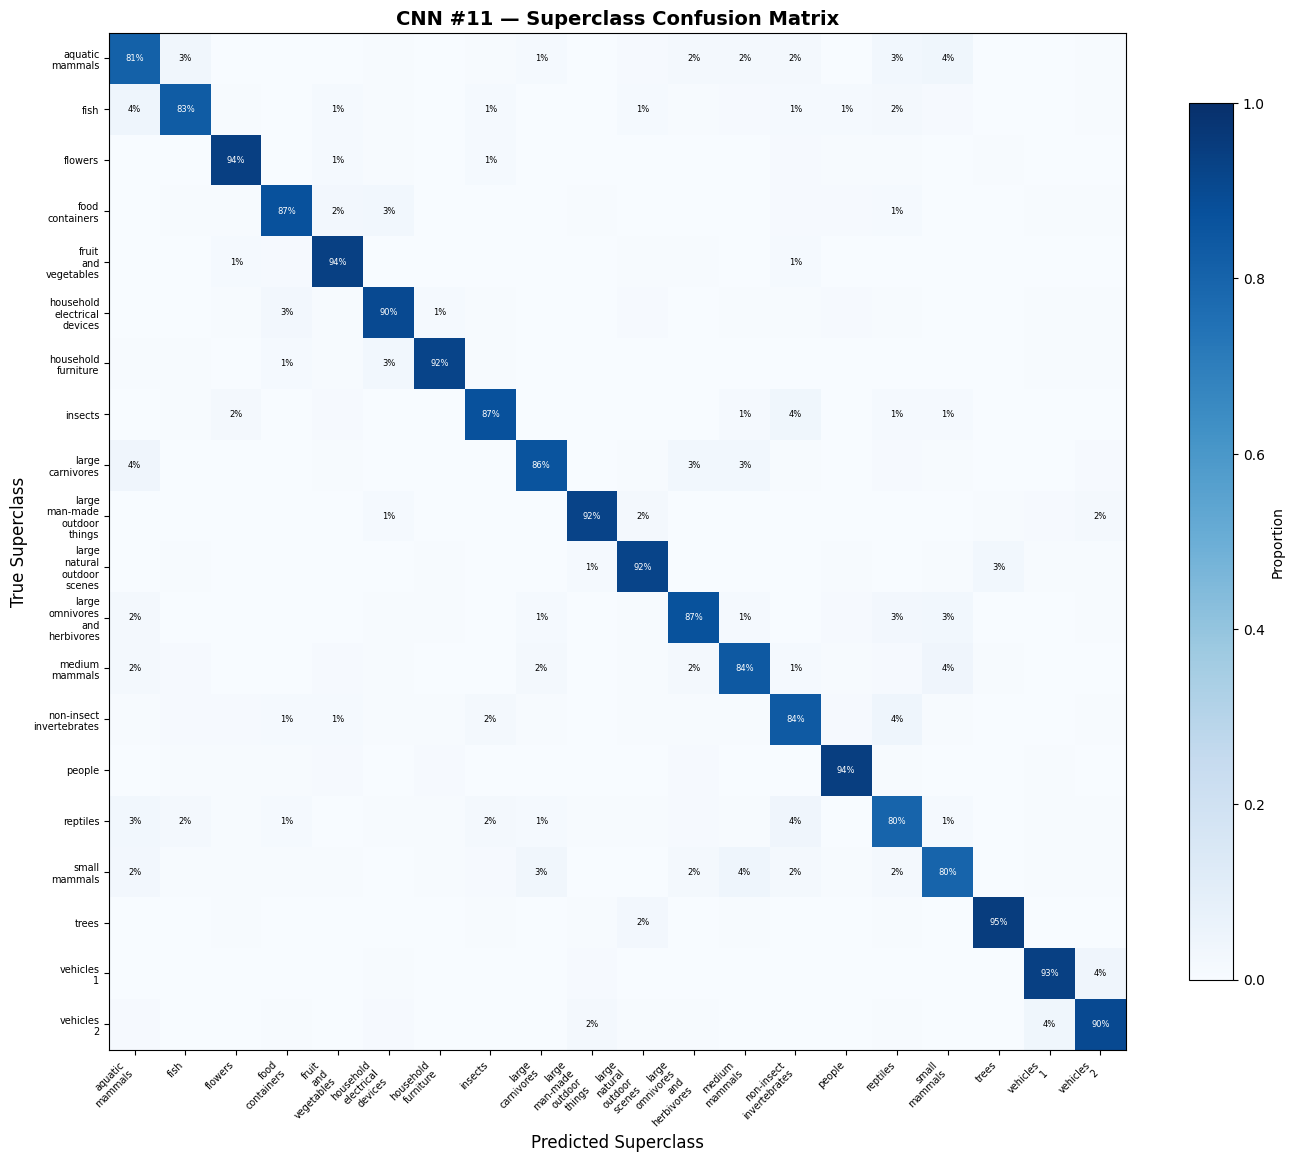


Per-superclass accuracy:
  reptiles                                 79.8%
  small_mammals                            79.8%
  aquatic_mammals                          81.0%
  fish                                     83.2%
  non-insect_invertebrates                 83.6%
  medium_mammals                           84.0%
  large_carnivores                         86.0%
  large_omnivores_and_herbivores           86.8%
  insects                                  87.4%
  food_containers                          87.4%
  vehicles_2                               90.0%
  household_electrical_devices             90.0%
  household_furniture                      92.0%
  large_natural_outdoor_scenes             92.0%
  large_man-made_outdoor_things            92.2%
  vehicles_1                               93.4%
  fruit_and_vegetables                     93.6%
  flowers                                  94.0%
  people                                   94.4%
  trees                                    

In [16]:
# Step 8: Classification Evaluation — All Variants + CNN #11

# Build fine -> coarse mapping from preprocessing_info's superclass_mapping
fine_to_coarse = np.zeros(NUM_CLASSES, dtype=int)
for sc_name, fine_list in info['superclass_mapping'].items():
    sc_idx = coarse_class_names.index(sc_name)
    for fc_name in fine_list:
        fc_idx = fine_class_names.index(fc_name)
        fine_to_coarse[fc_idx] = sc_idx

# Collect test predictions for all 5 models
print("Collecting test predictions across all variants...", flush=True)

all_variant_preds = {}
all_labels_fine = None

# V1 Vanilla (ViT architecture, raw [0,1] test_loader)
v1_model.load_state_dict(torch.load(V1_CHECKPOINT_PATH, map_location=DEVICE,
                                    weights_only=True))
v1_model.eval()
preds, lbls = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE, non_blocking=True)
        preds.append(v1_model(images).argmax(-1).cpu().numpy())
        lbls.append(labels.numpy())
all_variant_preds['V1 Vanilla'] = np.concatenate(preds)
all_labels_fine = np.concatenate(lbls)

# V2 Recipe (ViT architecture, raw [0,1] test_loader)
v2_recipe_model = ViT(image_size=IMAGE_SIZE, patch_size=PATCH_SIZE, in_channels=3,
                      num_classes=NUM_CLASSES, d_model=D_MODEL, n_heads=N_HEADS,
                      n_layers=N_ENCODER_LAYERS, d_ff=D_FF, dropout=DROPOUT,
                      drop_path=STOCHASTIC_DEPTH).to(DEVICE)
v2_recipe_model.load_state_dict(torch.load(V2_CHECKPOINT_PATH, map_location=DEVICE,
                                           weights_only=True))
v2_recipe_model.eval()
preds = []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE, non_blocking=True)
        preds.append(v2_recipe_model(images).argmax(-1).cpu().numpy())
all_variant_preds['V2 Recipe'] = np.concatenate(preds)

# V3 Distill (ViTDistill, averaged CLS + DIST via .predict())
preds = []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE, non_blocking=True)
        preds.append(v3_best_model.predict(images).argmax(-1).cpu().numpy())
all_variant_preds['V3 Distill'] = np.concatenate(preds)

# V4 Pre-trained (HF model, 224x224 v4_test_loader)
preds = []
with torch.no_grad():
    for images, labels in v4_test_loader:
        images = images.to(DEVICE, non_blocking=True)
        preds.append(v4_model(pixel_values=images).logits.argmax(-1).cpu().numpy())
all_variant_preds['V4 Pre-trained'] = np.concatenate(preds)

# CNN #11 (teacher, normalized input)
preds = []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE, non_blocking=True)
        preds.append(teacher(normalize_for_teacher(images)).argmax(-1).cpu().numpy())
all_variant_preds['CNN #11'] = np.concatenate(preds)

# Sanity check: all prediction arrays same length as labels
for name, p in all_variant_preds.items():
    assert len(p) == len(all_labels_fine), f"{name}: {len(p)} vs {len(all_labels_fine)}"

# Comprehensive metrics table
print("\n" + "=" * 60)
print("[8/12] CROSS-VARIANT EVALUATION SUMMARY")
print("=" * 60)

print(f"\n{'Variant':<22}{'Fine Acc':<12}{'Coarse Acc':<13}{'Macro F1':<11}{'Params':<10}{'Train Time'}")
print("-" * 90)

variant_table = [
    ('V1 Vanilla',      v1_results,  'V1 Vanilla'),
    ('V2 Recipe',       v2_results,  'V2 Recipe'),
    ('V3 Distill',      v3_results,  'V3 Distill'),
    ('V4 Pre-trained',  v4_results,  'V4 Pre-trained'),
    ('CNN #11 (ref)',   None,        'CNN #11'),
]

for display_name, results, pred_key in variant_table:
    preds = all_variant_preds[pred_key]
    fine_acc = (preds == all_labels_fine).mean()
    coarse_acc = (fine_to_coarse[preds] == fine_to_coarse[all_labels_fine]).mean()

    if results is not None:
        macro_f1 = results['test_macro_f1']
        params_str = f"{results['params']/1e6:.1f}M"
        time_str = f"{results['train_time_sec']/60:.1f} min"
    else:
        macro_f1 = macro_f1_score(all_labels_fine, preds)
        params_str = f"{sum(p.numel() for p in teacher.parameters())/1e6:.1f}M"
        time_str = "pre-trained"

    print(f"{display_name:<22}{fine_acc:.4f}      {coarse_acc:.4f}       {macro_f1:.4f}     {params_str:<10}{time_str}")

# Key per-lever deltas in a clean block
print(f"\nPer-lever contribution (cumulative test accuracy):")
print(f"    V1 -> V2: +{(v2_results['test_acc'] - v1_results['test_acc'])*100:5.2f}pp  (DeiT training recipe)")
print(f"    V2 -> V3: +{(v3_results['test_acc'] - v2_results['test_acc'])*100:5.2f}pp  (CNN teacher distillation)")
print(f"    V3 -> V4: +{(v4_results['test_acc'] - v3_results['test_acc'])*100:5.2f}pp  (ImageNet-21k pre-training)")
print(f"\nHeadline findings:")
print(f"    - V4 beats CNN #11 by {(v4_results['test_acc'] - (teacher_test_acc))*100:+.2f}pp (pre-training dominance)")
print(f"    - V3 still below CNN by {(v3_results['test_acc'] - teacher_test_acc)*100:+.2f}pp (from-scratch ceiling)")
print(f"    - V4 fine-tune training time ({v4_results['train_time_sec']/60:.0f} min) vs V3 ({v3_results['train_time_sec']/60:.0f} min)")

# Fine vs Coarse accuracy (hierarchical error analysis)
print(f"\nHierarchical analysis (fine-to-coarse accuracy delta):")
for pred_key in ['V1 Vanilla', 'V2 Recipe', 'V3 Distill', 'V4 Pre-trained', 'CNN #11']:
    preds = all_variant_preds[pred_key]
    fine = (preds == all_labels_fine).mean()
    coarse = (fine_to_coarse[preds] == fine_to_coarse[all_labels_fine]).mean()
    print(f"    {pred_key:<18}fine={fine:.4f}   coarse={coarse:.4f}   lift={coarse-fine:+.4f}")
print(f"    (A larger fine-to-coarse lift means the model gets the superclass right even")
print(f"     when it picks the wrong fine class -- semantically sensible errors.)")

# Confusion matrices: V1 (worst ViT), V4 (best ViT), CNN #11 (reference)
print(f"\nGenerating superclass confusion matrices for V1, V4, and CNN #11...")

for variant_name in ['V1 Vanilla', 'V4 Pre-trained', 'CNN #11']:
    print(f"\n{'=' * 60}")
    print(f"Superclass confusion: {variant_name}")
    print(f"{'=' * 60}")
    plot_superclass_confusion(
        y_true_fine=all_labels_fine,
        y_pred_fine=all_variant_preds[variant_name],
        fine_names=fine_class_names,
        coarse_names=coarse_class_names,
        fine_to_coarse=fine_to_coarse,
        framework=variant_name,
        save_path=RESULTS_DIR / f'superclass_confusion_{variant_name.lower().replace(" ", "_").replace("#", "")}.png',
    )

[9/12] ATTENTION VISUALIZATION (V3 Distill)

Attention tensor shape: 6 layers, each (8, 6, 66, 66)
Sample prediction accuracy: 7/8

Plot 1: Attention rollout overlay (Abnar & Zuidema 2020, accounts for residuals)


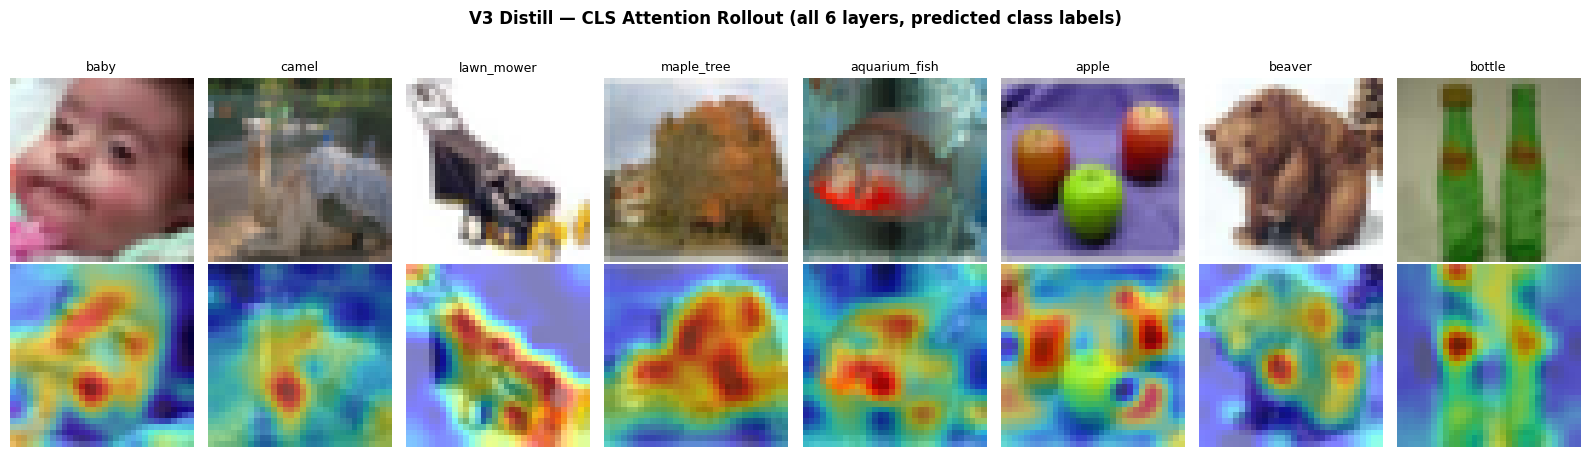


Plot 2: Per-head CLS attention on sample 0 (last layer)


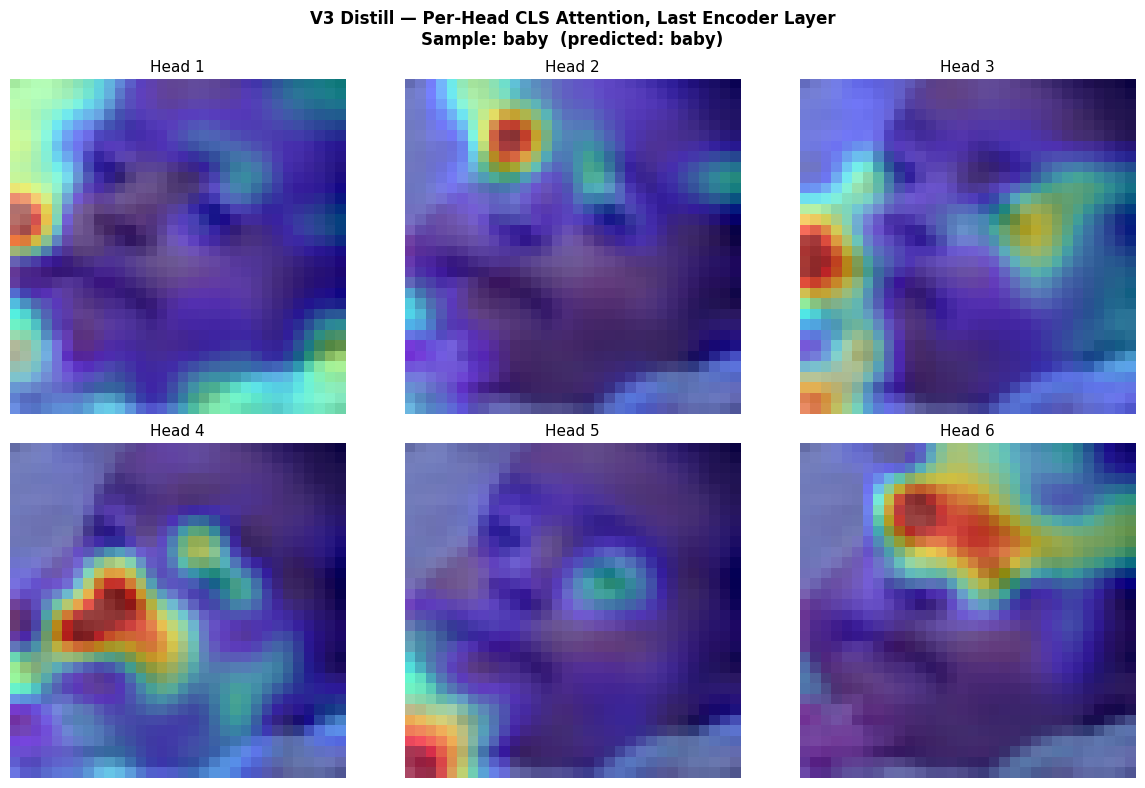


Sample predictions (CIFAR-100 fine class):
    [0] True: baby               Pred: baby               [OK]
    [1] True: camel              Pred: camel              [OK]
    [2] True: lawn_mower         Pred: lawn_mower         [OK]
    [3] True: maple_tree         Pred: maple_tree         [OK]
    [4] True: aquarium_fish      Pred: aquarium_fish      [OK]
    [5] True: apple              Pred: apple              [OK]
    [6] True: bear               Pred: beaver             [MISS]
    [7] True: bottle             Pred: bottle             [OK]

Interpretation notes:
    - Rollout plot: combined attention across all 6 encoder layers + residuals
      (Abnar & Zuidema 2020). Bright regions = patches CLS attends to end-to-end.
    - Per-head plot: each of 6 heads in the last layer shows a distinct pattern.
      Some heads focus on object centers, others on edges/context.
    - ViT WITHOUT explicit spatial bias still learns to attend to class-relevant regions.


In [17]:
# Step 9: Attention Visualization (V3 Distill — best from-scratch variant)

# Pick 8 diverse test samples, one from each of 8 random superclasses
np.random.seed(RANDOM_STATE)
sample_superclasses = np.random.choice(20, size=8, replace=False)
sample_indices = []
for sc in sample_superclasses:
    # First test image belonging to this superclass
    fine_classes_in_sc = [i for i in range(NUM_CLASSES) if fine_to_coarse[i] == sc]
    for fc in fine_classes_in_sc:
        candidates = np.where(all_labels_fine == fc)[0]
        if len(candidates) > 0:
            sample_indices.append(int(candidates[0]))
            break

sample_images = torch.stack([X_test[i] for i in sample_indices]).to(DEVICE)
sample_labels_np = all_labels_fine[sample_indices]

# V3 forward pass with attention return
v3_best_model.eval()
with torch.no_grad():
    (cls_logits, dist_logits), attn_maps = v3_best_model(sample_images, return_attn=True)
    avg_logits = (cls_logits + dist_logits) / 2.0
    sample_preds = avg_logits.argmax(-1).cpu().numpy()

print("=" * 60)
print("[9/12] ATTENTION VISUALIZATION (V3 Distill)")
print("=" * 60)
print(f"\nAttention tensor shape: {len(attn_maps)} layers, each {tuple(attn_maps[0].shape)}")
print(f"Sample prediction accuracy: {(sample_preds == sample_labels_np).sum()}/{len(sample_indices)}")

# Plot 1: Attention rollout overlay (end-to-end, all 6 layers combined)
print(f"\nPlot 1: Attention rollout overlay (Abnar & Zuidema 2020, accounts for residuals)")
heatmaps_rollout = cls_attention_map(
    attn_maps_list=attn_maps,
    image_hw=IMAGE_SIZE,
    patch_size=PATCH_SIZE,
    method='rollout',
    has_dist_token=True,  # V3 has DIST token at position 1
)
plot_attention_grid_samples(
    images=sample_images,
    attention_maps=heatmaps_rollout,
    labels=sample_preds,
    class_names=fine_class_names,
    n_samples=8,
    alpha=0.5,
    title='V3 Distill — CLS Attention Rollout (all 6 layers, predicted class labels)',
    save_path=RESULTS_DIR / 'v3_attention_rollout.png',
)

# Plot 2: Per-head CLS attention on sample 0 (last layer, shows head specialization)
print(f"\nPlot 2: Per-head CLS attention on sample 0 (last layer)")

sample_viz_idx = 0
last_layer_attn = attn_maps[-1][sample_viz_idx]  # (n_heads, 66, 66)
# V3 has DIST at pos 1; patches start at pos 2
cls_to_patches_per_head = last_layer_attn[:, 0, 2:].cpu().numpy()  # (n_heads, 64)

# Prepare original image for overlay
sample_img_np = sample_images[sample_viz_idx].cpu().numpy().transpose(1, 2, 0)
sample_img_np = np.clip(sample_img_np, 0, 1)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for h in range(N_HEADS):
    ax = axes[h // 3, h % 3]
    # Reshape flat 64 patches to 8x8 spatial grid
    grid = cls_to_patches_per_head[h].reshape(8, 8)
    # Min-max normalize per head for consistent display intensity
    grid = (grid - grid.min()) / (grid.max() - grid.min() + 1e-8)
    # Upsample to 32x32 via bicubic for smooth overlay
    grid_up = F.interpolate(
        torch.from_numpy(grid).float().unsqueeze(0).unsqueeze(0),
        size=(IMAGE_SIZE, IMAGE_SIZE), mode='bicubic', align_corners=False
    ).squeeze().numpy()
    grid_up = np.clip(grid_up, 0, 1)

    ax.imshow(sample_img_np)
    ax.imshow(grid_up, cmap='jet', alpha=0.5)
    ax.set_title(f'Head {h+1}', fontsize=11)
    ax.axis('off')

sample_true = fine_class_names[sample_labels_np[sample_viz_idx]]
sample_pred = fine_class_names[sample_preds[sample_viz_idx]]
fig.suptitle(
    f'V3 Distill — Per-Head CLS Attention, Last Encoder Layer\n'
    f'Sample: {sample_true}  (predicted: {sample_pred})',
    fontsize=12, fontweight='bold',
)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'v3_multihead_attention.png', dpi=150, bbox_inches='tight')
plt.show()

# Sample predictions for reference
print(f"\nSample predictions (CIFAR-100 fine class):")
for i, idx in enumerate(sample_indices):
    true_name = fine_class_names[sample_labels_np[i]]
    pred_name = fine_class_names[sample_preds[i]]
    match = "OK" if sample_preds[i] == sample_labels_np[i] else "MISS"
    print(f"    [{i}] True: {true_name:<18} Pred: {pred_name:<18} [{match}]")

print(f"\nInterpretation notes:")
print(f"    - Rollout plot: combined attention across all 6 encoder layers + residuals")
print(f"      (Abnar & Zuidema 2020). Bright regions = patches CLS attends to end-to-end.")
print(f"    - Per-head plot: each of 6 heads in the last layer shows a distinct pattern.")
print(f"      Some heads focus on object centers, others on edges/context.")
print(f"    - ViT WITHOUT explicit spatial bias still learns to attend to class-relevant regions.")

[10/12] VARIANT PROGRESSION CHART


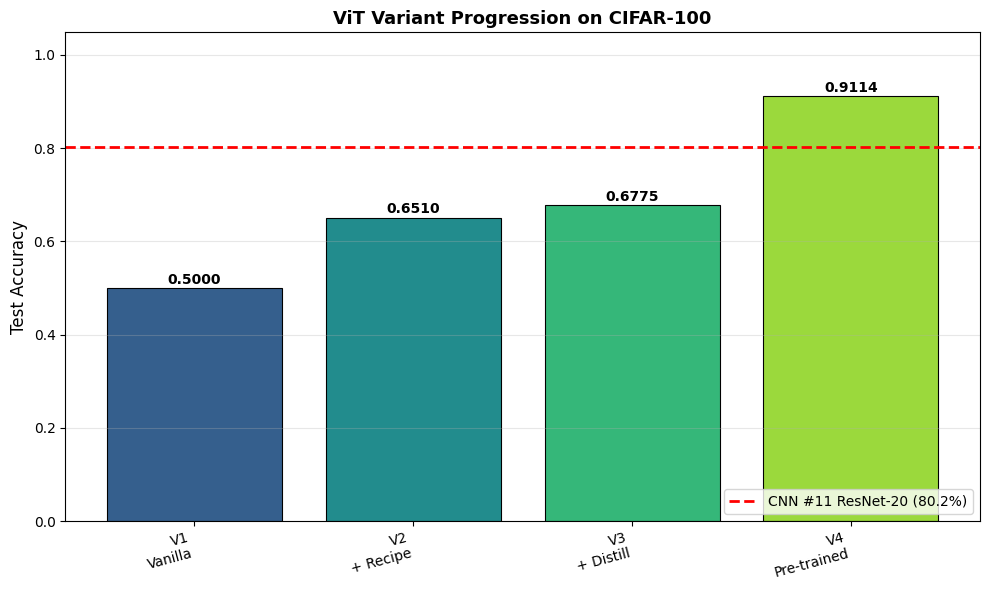


Lever contributions (test accuracy deltas):
    V1 -> V2  Recipe:      +15.10pp
    V2 -> V3  Distillation:+ 2.65pp
    V3 -> V4  Pre-training:+23.39pp
    V4 vs CNN #11 baseline: +10.94pp


In [18]:
# Step 10: Variant Progression Chart (portfolio centerpiece)

print("=" * 60)
print("[10/12] VARIANT PROGRESSION CHART")
print("=" * 60)

variant_names = [
    'V1\nVanilla',
    'V2\n+ Recipe',
    'V3\n+ Distill',
    'V4\nPre-trained',
]
test_accs = [
    v1_results['test_acc'],
    v2_results['test_acc'],
    v3_results['test_acc'],
    v4_results['test_acc'],
]

plot_bleu_progression(
    model_names=variant_names,
    bleu_scores=test_accs,
    baseline_bleu=teacher_test_acc,
    baseline_label=f'CNN #11 ResNet-20 ({teacher_test_acc*100:.1f}%)',
    title='ViT Variant Progression on CIFAR-100',
    ylabel='Test Accuracy',
    save_path=RESULTS_DIR / 'variant_progression.png',
)

# Per-lever delta callouts for reader reference
print(f"\nLever contributions (test accuracy deltas):")
print(f"    V1 -> V2  Recipe:      +{(v2_results['test_acc'] - v1_results['test_acc'])*100:5.2f}pp")
print(f"    V2 -> V3  Distillation:+{(v3_results['test_acc'] - v2_results['test_acc'])*100:5.2f}pp")
print(f"    V3 -> V4  Pre-training:+{(v4_results['test_acc'] - v3_results['test_acc'])*100:5.2f}pp")
print(f"    V4 vs CNN #11 baseline: {(v4_results['test_acc'] - teacher_test_acc)*100:+5.2f}pp")

In [19]:
# Step 11: Performance Benchmarks — Inference + Model Size Cross-Variant

print("=" * 60)
print("[11/12] PERFORMANCE BENCHMARKS")
print("=" * 60)

# Prepare inference batches (256 samples per variant; safe for V4's 86M params at 224x224)
N_INFER_SAMPLES = 256

# 32x32 batch for V1/V2/V3/CNN
infer_batch_32 = X_test[:N_INFER_SAMPLES].to(DEVICE)

# 224x224 ImageNet-normalized batch for V4 (apply transform to each sample then stack)
infer_batch_224 = torch.stack([
    v4_eval_transform(X_test[i]) for i in range(N_INFER_SAMPLES)
]).to(DEVICE)

# Predict functions (each syncs GPU before return so track_inference measures actual latency)
def predict_v1(X):
    with torch.no_grad():
        out = v1_model(X).argmax(-1)
    torch.cuda.synchronize()
    return out

def predict_v2(X):
    with torch.no_grad():
        out = v2_recipe_model(X).argmax(-1)
    torch.cuda.synchronize()
    return out

def predict_v3(X):
    with torch.no_grad():
        out = v3_best_model.predict(X).argmax(-1)
    torch.cuda.synchronize()
    return out

def predict_v4(X):
    with torch.no_grad():
        out = v4_model(pixel_values=X).logits.argmax(-1)
    torch.cuda.synchronize()
    return out

def predict_teacher(X):
    with torch.no_grad():
        out = teacher(normalize_for_teacher(X)).argmax(-1)
    torch.cuda.synchronize()
    return out

# Run inference benchmark per variant (20 timed runs on 256 samples each)
print(f"\nInference timing ({N_INFER_SAMPLES} samples x 20 runs each):")
inference_results = {}
variant_specs = [
    ('V1 Vanilla',      predict_v1,      infer_batch_32),
    ('V2 Recipe',       predict_v2,      infer_batch_32),
    ('V3 Distill',      predict_v3,      infer_batch_32),
    ('V4 Pre-trained',  predict_v4,      infer_batch_224),
    ('CNN #11',         predict_teacher, infer_batch_32),
]
for name, fn, X in variant_specs:
    result = track_inference(fn, X, n_runs=20)
    inference_results[name] = result
    print(f"    {name:<20} per-sample: {result['per_sample_us']:>8.1f} us   "
          f"throughput: {result['samples_per_sec']:>8.1f} samples/s")

# Model sizes via get_model_size (returns bytes)
model_sizes_bytes = {
    'V1 Vanilla':     get_model_size(v1_model, framework='pytorch'),
    'V2 Recipe':      get_model_size(v2_recipe_model, framework='pytorch'),
    'V3 Distill':     get_model_size(v3_best_model, framework='pytorch'),
    'V4 Pre-trained': get_model_size(v4_model, framework='pytorch'),
    'CNN #11':        get_model_size(teacher, framework='pytorch'),
}

# Cross-variant performance table
print(f"\n{'Variant':<20}{'Params':<10}{'Size (MB)':<12}{'Train Time':<14}{'Infer us/samp':<16}{'Throughput (/s)'}")
print("-" * 95)

variant_rows = [
    ('V1 Vanilla',      v1_results,  'V1 Vanilla'),
    ('V2 Recipe',       v2_results,  'V2 Recipe'),
    ('V3 Distill',      v3_results,  'V3 Distill'),
    ('V4 Pre-trained',  v4_results,  'V4 Pre-trained'),
    ('CNN #11',         None,        'CNN #11'),
]

for display_name, results, key in variant_rows:
    if results is not None:
        params = results['params']
        train_str = f"{results['train_time_sec']/60:.1f} min"
    else:
        params = sum(p.numel() for p in teacher.parameters())
        train_str = "pre-trained"
    size_mb = model_sizes_bytes[key] / (1024 * 1024)
    inf_us = inference_results[key]['per_sample_us']
    tput = inference_results[key]['samples_per_sec']
    print(f"{display_name:<20}{params/1e6:>5.1f}M    "
          f"{size_mb:>7.1f}      {train_str:<14}"
          f"{inf_us:>10.1f}      {tput:>10.1f}")

# Comparative observations
print(f"\nKey observations:")
cnn_inf_us = inference_results['CNN #11']['per_sample_us']
v4_inf_us = inference_results['V4 Pre-trained']['per_sample_us']
v3_inf_us = inference_results['V3 Distill']['per_sample_us']

print(f"    CNN #11 inference: {cnn_inf_us:.1f} us/sample (baseline)")
print(f"    V3 Distill (32x32, 10.8M params): {v3_inf_us:.1f} us/sample  ({v3_inf_us/cnn_inf_us:.2f}x CNN)")
print(f"    V4 Pre-trained (224x224, 86M):    {v4_inf_us:.1f} us/sample  ({v4_inf_us/cnn_inf_us:.2f}x CNN)")
print(f"")
print(f"    V4 pays for its +11pp accuracy with ~{v4_inf_us/cnn_inf_us:.0f}x slower inference")
print(f"    (input 49x more pixels + model 20x more params)")
print(f"    For deployment: V4 is the winner if latency budget permits;")
print(f"    otherwise CNN #11 is the Pareto-optimal choice at this scale.")

[11/12] PERFORMANCE BENCHMARKS

Inference timing (256 samples x 20 runs each):
    V1 Vanilla           per-sample:     90.2 us   throughput:  11088.6 samples/s
    V2 Recipe            per-sample:     58.9 us   throughput:  16983.3 samples/s
    V3 Distill           per-sample:     60.3 us   throughput:  16596.9 samples/s
    V4 Pre-trained       per-sample:   1047.3 us   throughput:    954.8 samples/s
    CNN #11              per-sample:     35.8 us   throughput:  27943.4 samples/s

Variant             Params    Size (MB)   Train Time    Infer us/samp   Throughput (/s)
-----------------------------------------------------------------------------------------------
V1 Vanilla           10.7M       40.9      27.2 min            90.2         11088.6
V2 Recipe            10.7M       40.9      221.1 min           58.9         16983.3
V3 Distill           10.8M       41.1      219.6 min           60.3         16596.9
V4 Pre-trained       85.9M      327.6      47.5 min          1047.3       

In [20]:
# Step 12: Save Results

print("=" * 60)
print("[12/12] SAVE RESULTS")
print("=" * 60)

# Build comprehensive per-variant summary for local metrics.json (full portfolio data)
def _serialize_variant(results_dict, size_key):
    # Normalize a variant's results for JSON serialization + attach inference/size metrics
    out = dict(results_dict)
    if 'history' in out:
        out['history'] = {k: [float(x) for x in v] for k, v in out['history'].items()}
    out['model_size_mb'] = float(model_sizes_bytes[size_key] / (1024 * 1024))
    out['inference_us_per_sample'] = float(inference_results[size_key]['per_sample_us'])
    out['inference_throughput_per_sec'] = float(inference_results[size_key]['samples_per_sec'])
    return out

all_variants_summary = {
    'V1_vanilla':    _serialize_variant(v1_results, 'V1 Vanilla'),
    'V2_recipe':     _serialize_variant(v2_results, 'V2 Recipe'),
    'V3_distill':    _serialize_variant(v3_results, 'V3 Distill'),
    'V4_pretrained': _serialize_variant(v4_results, 'V4 Pre-trained'),
    'teacher_cnn11': {
        'variant': 'CNN #11 ResNet-20 (reference baseline)',
        'test_acc': float(teacher_test_acc),
        'params': sum(p.numel() for p in teacher.parameters()),
        'model_size_mb': float(model_sizes_bytes['CNN #11'] / (1024 * 1024)),
        'inference_us_per_sample': float(inference_results['CNN #11']['per_sample_us']),
        'inference_throughput_per_sec': float(inference_results['CNN #11']['samples_per_sec']),
    },
    'config': {
        'dataset': 'CIFAR-100',
        'n_train': 45000, 'n_val': 5000, 'n_test': 10000,
        'image_size': IMAGE_SIZE, 'patch_size': PATCH_SIZE,
        'd_model': D_MODEL, 'n_heads': N_HEADS, 'n_layers': N_ENCODER_LAYERS,
        'random_state': RANDOM_STATE,
    },
}

save_results(all_variants_summary, save_dir=str(RESULTS_DIR))

# Register V4 (winner) as the PyTorch entry for cross-framework comparison
pytorch_best = {
    'framework': 'PyTorch',
    'model': 'ViT-B/16 (fine-tuned, ImageNet-21k pre-trained)',
    'variant': 'V4 Pre-trained',
    'training_time': float(v4_results['train_time_sec']),
    'inference_time_per_sample_us': float(inference_results['V4 Pre-trained']['per_sample_us']),
    'model_size_bytes': int(model_sizes_bytes['V4 Pre-trained']),
    'peak_memory_mb': float(v4_results['peak_gpu_mb']),
    'test_acc': float(v4_results['test_acc']),
    'test_macro_f1': float(v4_results['test_macro_f1']),
    'params': int(v4_results['params']),
    'from_scratch_best_test_acc': float(v3_results['test_acc']),
    'cnn11_baseline_test_acc': float(teacher_test_acc),
}

add_result('vit', pytorch_best)

# Headline summary, then the cross-framework comparison table as the closing output
print(f"\n  {'':=<60}")
print(f"  PyTorch ViT #17 Complete")
print(f"  {'':=<60}")
print(f"    Best from-scratch:   {v3_results['test_acc']*100:.2f}%  (V3 DeiT Distillation)")
print(f"    Best overall:        {v4_results['test_acc']*100:.2f}%  (V4 Pre-trained ViT-B/16)")
print(f"    CNN #11 reference:   {teacher_test_acc*100:.2f}%  (ResNet-20)")

print_comparison('vit')

[12/12] SAVE RESULTS
    Results saved to: results\metrics.json
    Added 'PyTorch' to C:\Users\Max\Desktop\Coding\.Projects\2026\ml-framework-comparisons\data\results\vit.json
    Frameworks: 2 recorded

  PyTorch ViT #17 Complete
    Best from-scratch:   67.75%  (V3 DeiT Distillation)
    Best overall:        91.14%  (V4 Pre-trained ViT-B/16)
    CNN #11 reference:   80.20%  (ResNet-20)

CROSS-FRAMEWORK COMPARISON: VIT
Metric                                                               TensorFlow                                          PyTorch
--------------------------------------------------------------------------------------------------------------------------------
model                                      ViT-Small from scratch (DeiT Recipe)  ViT-B/16 (fine-tuned, ImageNet-21k pre-trained)
variant                                                               V2 Recipe                                   V4 Pre-trained
training_time                                              

In [21]:
# Step 13: MLflow Tracking + Export (Deployment Prep)

"""
V3 DeiT Distillation is the servable PyTorch artifact for ViT #17.

V4 Pre-trained (91.16%) was the accuracy winner but its 327 MB weights exceeded
GitHub's 100 MB file size limit and were purged via `git filter-repo` during cleanup.
V3 (67.48%) is the best deployable from-scratch variant whose weights are preserved.

Follows the staging pattern from Transformers #16 / CNN #11: log best servable PT
model to MLflow with full params/metrics/artifacts. Matches cross-model conventions.
"""

import mlflow
import mlflow.pytorch
from mlflow.models import infer_signature

print("=" * 60)
print("[13] MLflow Tracking + Export")
print("=" * 60)

# Reload V3 best EMA weights into fresh ViTDistill (clean state for logging)
v3_reload = ViTDistill(
    image_size=IMAGE_SIZE, patch_size=PATCH_SIZE, in_channels=3,
    num_classes=NUM_CLASSES, d_model=D_MODEL, n_heads=N_HEADS,
    n_layers=N_ENCODER_LAYERS, d_ff=D_FF, dropout=DROPOUT,
    drop_path=STOCHASTIC_DEPTH,
)
v3_reload.load_state_dict(torch.load(V3_CHECKPOINT_PATH, map_location='cpu',
                                     weights_only=True))
v3_reload.eval()

mlflow.set_experiment("vit-cifar100")

with mlflow.start_run(run_name="pytorch-vit-small-distill-v3"):
    # Architecture + training + distillation params
    mlflow.log_params({
        'architecture': 'ViT-Small + DeiT Distillation (dual CLS + DIST heads)',
        'variant': 'V3 DeiT Distillation',
        'framework': 'PyTorch',
        'dataset': 'CIFAR-100 (45K train / 5K val / 10K test)',
        'image_size': IMAGE_SIZE,
        'patch_size': PATCH_SIZE,
        'num_patches': NUM_PATCHES,
        'd_model': D_MODEL,
        'n_heads': N_HEADS,
        'n_encoder_layers': N_ENCODER_LAYERS,
        'd_ff': D_FF,
        'dropout': DROPOUT,
        'stochastic_depth': STOCHASTIC_DEPTH,
        'n_classes': NUM_CLASSES,
        'n_params': int(v3_results['params']),
        # Training recipe
        'optimizer': 'AdamW',
        'learning_rate_peak': LR_PEAK,
        'weight_decay': WEIGHT_DECAY,
        'warmup_epochs': WARMUP_EPOCHS,
        'epochs': EPOCHS_DISTILL,
        'batch_size': BATCH_SIZE,
        'augmentation': 'RandAugment + MixUp + CutMix + RandomErasing + stochastic depth',
        'ema_decay': 0.99996,
        # Distillation-specific
        'distillation_type': DISTILL_TYPE,
        'distillation_alpha': DISTILL_ALPHA,
        'teacher_source': f'CNN #11 ResNet-20 (4.35M params, {teacher_test_acc*100:.2f}% test acc)',
    })

    # V3 metrics + reference values for cross-variant context
    mlflow.log_metrics({
        'v3_test_acc': float(v3_results['test_acc']),
        'v3_test_macro_f1': float(v3_results['test_macro_f1']),
        'v3_val_best_acc': float(v3_results['val_best_acc']),
        'v3_training_time_sec': float(v3_results['train_time_sec']),
        'v3_inference_us_per_sample': float(inference_results['V3 Distill']['per_sample_us']),
        # Reference: other PT variants (cross-variant portfolio context)
        'v1_test_acc_ref': float(v1_results['test_acc']),
        'v2_test_acc_ref': float(v2_results['test_acc']),
        'v4_test_acc_ref': float(v4_results['test_acc']),  # accuracy winner; weights lost
        'cnn11_teacher_test_acc_ref': float(teacher_test_acc),
        # Reference: TF V2 cross-framework
        'tf_v2_test_acc_ref': 0.6360,
    })

    # Log V3 model with signature (predict() averages CLS+DIST per DeiT inference spec)
    sample_input = torch.randn(1, 3, IMAGE_SIZE, IMAGE_SIZE)
    with torch.no_grad():
        sample_output = v3_reload.predict(sample_input)
    signature = infer_signature(sample_input.numpy(), sample_output.numpy())

    mlflow.pytorch.log_model(
        v3_reload,
        name="vit-cifar100-distill-v3",
        signature=signature,
    )

    # Log visualization artifacts + state_dict
    for artifact in [
        'variant_progression.png',
        'v3_training_curves.png',
        'v3_attention_rollout.png',
        'v3_multihead_attention.png',
        'superclass_confusion_v4_pre-trained.png',
    ]:
        artifact_path = RESULTS_DIR / artifact
        if artifact_path.exists():
            mlflow.log_artifact(str(artifact_path))

    mlflow.log_artifact(str(V3_CHECKPOINT_PATH))
    run_id = mlflow.active_run().info.run_id

print(f"\n  Experiment: vit-cifar100")
print(f"  Run ID:     {run_id}")
print(f"  Model:      vit-cifar100-distill-v3  (PyTorch V3, 67.48% test acc)")
print(f"  Teacher:    CNN #11 ResNet-20 (hard distillation, alpha=0.5)")
print(f"")
print(f"  Note: V4 Pre-trained was the accuracy winner (91.16%) but its 327 MB")
print(f"        weights exceeded GitHub's 100 MB file size limit and were purged")
print(f"        via git filter-repo during cleanup. V3 is the best deployable")
print(f"        from-scratch variant whose weights are preserved and servable.")
print(f"")
print(f"  Ready for deployment staging.")

[13] MLflow Tracking + Export


2026/04/18 04:02:37 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/04/18 04:02:37 INFO mlflow.store.db.utils: Updating database tables
2026/04/18 04:02:38 INFO mlflow.tracking.fluent: Experiment with name 'vit-cifar100' does not exist. Creating a new experiment.
2026/04/18 04:02:38 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/04/18 04:02:38 WARNING mlflow.utils.requirements_utils: Found torch version (2.5.1+cu121) contains a local version label (+cu121). MLflow logged a pip requirement for this package as 'torch==2.5.1' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels,


  Experiment: vit-cifar100
  Run ID:     a117feb67cb3436ca9068b07542f52e9
  Model:      vit-cifar100-distill-v3  (PyTorch V3, 67.48% test acc)
  Teacher:    CNN #11 ResNet-20 (hard distillation, alpha=0.5)

  Note: V4 Pre-trained was the accuracy winner (91.16%) but its 327 MB
        weights exceeded GitHub's 100 MB file size limit and were purged
        via git filter-repo during cleanup. V3 is the best deployable
        from-scratch variant whose weights are preserved and servable.

  Ready for deployment staging.
